# **GIAI ĐOẠN 1: PHÂN TÍCH VÀ DỰ BÁO NGUY CƠ BỎ HỌC CỦA SINH VIÊN**

## **Phần A. Chuẩn bị và làm sạch dữ liệu (Data Preprocessing)**

### **1. Giới thiệu tổng quan dữ liệu**

#### *1.1. Bối cảnh*

Bộ dữ liệu `academic_survival_longitudinal.csv` lưu trữ thông tin học tập, nhân khẩu học và tình trạng tài chính của sinh viên qua các học kỳ.

Mục tiêu phân tích là áp dụng toán học và học máy để dự đoán sớm nguy cơ bỏ học (Dropout Risk) của sinh viên trong học kỳ tiếp theo, từ đó cung cấp cảnh báo cho hệ thống SmartEdu AI phân bổ Mentor hỗ trợ kịp thời.

In [ ]:
# Hiển thị dữ liệu
import pandas as pd
df = pd.read_csv('E:/FPT/HocKy4/MATHEMATICS_FOR_ML/ITA201_Assigment/SMARTEDU-AI/data/academic_survival_longitudinal.csv')
pd.options.display.max_columns = 100
df.head()

,Student_ID,Age,Gender,First_Generation,Family_Income,Household_Size,Housing_Status,Scholarship,Tuition_Base,Semester,Course_Load,Work_Hours,Emergency_Expense,Sem_GPA,Attendance,LMS_Logins,Advising_Visits,Failed_Courses,Financial_Stress,Target_Dropout_Next_Sem,End_of_Semester_Status,Censored
0,STU_00001,18,Female,0,15000.0,2,Off-Campus,0,15000,1,15,18.4,0.0,2.85,85.8,67.0,0,0,1.7,0,Enrolled,0
1,STU_00001,18,Female,0,15000.0,2,Off-Campus,0,15000,2,15,23.1,0.0,2.73,81.0,89.0,1,0,3.1,0,Enrolled,0
2,STU_00001,18,Female,0,15000.0,2,Off-Campus,0,15000,3,15,19.1,0.0,2.60,78.3,60.0,0,2,3.0,0,Enrolled,0
3,STU_00001,18,Female,0,15000.0,2,Off-Campus,0,15000,4,15,26.5,0.0,2.34,77.2,59.0,2,3,5.1,0,Enrolled,0
4,STU_00001,18,Female,0,15000.0,2,Off-Campus,0,15000,5,18,25.4,0.0,1.90,79.3,53.0,1,2,3.6,0,Enrolled,1
5,STU_00002,20,Male,1,80000.0,5,On-Campus,1,25000,1,12,0.1,0.0,2.38,84.2,71.0,1,1,1.4,0,Enrolled,0
6,STU_00002,20,Male,1,80000.0,5,On-Campus,1,25000,2,12,4.1,0.0,2.36,82.0,63.0,0,1,1.0,0,Enrolled,1
7,STU_00003,24,Male,1,136000.0,3,On-Campus,0,15000,1,15,7.3,0.0,3.00,90.8,82.0,0,1,1.0,0,Enrolled,0
8,STU_00003,24,Male,1,NaN,3,On-Campus,0,15000,2,15,13.9,0.0,2.97,87.6,80.0,1,0,1.2,0,Enrolled,0
9,STU_00003,24,Male,1,136000.0,3,On-Campus,0,15000,3,15,3.3,0.0,2.78,87.7,57.0,0,1,1.0,0,Enrolled,0


#### *1.2. Quy mô dữ liệu*

In [2]:
# Kích thước dữ liệu
print(f"Kích thước không gian dữ liệu (X): {df.shape[0]} dòng (mẫu) x {df.shape[1]} cột (chiều không gian)\n")

Kích thước không gian dữ liệu (X): 79239 dòng (mẫu) x 22 cột (chiều không gian)



*   **Số lượng mẫu (Rows):** 79.239 bản ghi
*   **Số chiều (Columns):** 22 đặc trưng.

#### *1.3. Phân loại đặc trưng*

In [3]:
# Kiểu dữ liệu
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 79239 entries, 0 to 79238
Data columns (total 22 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Student_ID               79239 non-null  str    
 1   Age                      79239 non-null  int64  
 2   Gender                   79239 non-null  str    
 3   First_Generation         79239 non-null  int64  
 4   Family_Income            75635 non-null  float64
 5   Household_Size           79239 non-null  int64  
 6   Housing_Status           79239 non-null  str    
 7   Scholarship              79239 non-null  int64  
 8   Tuition_Base             79239 non-null  int64  
 9   Semester                 79239 non-null  int64  
 10  Course_Load              79239 non-null  int64  
 11  Work_Hours               79239 non-null  float64
 12  Emergency_Expense        79239 non-null  float64
 13  Sem_GPA                  79239 non-null  float64
 14  Attendance               79239 no

Bộ dữ liệu đáp ứng đầy đủ cấu trúc biến số yêu cầu của bài toán:
1.  **Trường định danh (ID):** `Student_ID` (Dùng để định danh và xây dựng đồ thị tương tác sinh viên).
2.  **Đặc trưng số (Numerical Features) - 14 biến:** `Age` (Tuổi), `Family_Income` (Thu nhập), `Tuition_Base` (Học phí), `Course_Load` (Số tín chỉ), `Work_Hours` (Giờ làm thêm), `Emergency_Expense` (Chi phí khẩn cấp), `Sem_GPA` (Điểm trung bình kỳ), `Attendance` (Tỷ lệ chuyên cần), `LMS_Logins` (Số lần đăng nhập học liệu), `Advising_Visits` (Số lần gặp cố vấn), `Failed_Courses` (Số môn trượt), `Financial_Stress` (Chỉ số áp lực tài chính), `Household_Size`, `Semester`. *(Thỏa mãn yêu cầu $\ge$ 6 biến số).*
3.  **Đặc trưng phân loại (Categorical Features) - 5 biến:** `Gender` (Giới tính), `First_Generation` (Sinh viên thế hệ đầu), `Housing_Status` (Tình trạng chỗ ở), `Scholarship` (Học bổng), `End_of_Semester_Status` (Trạng thái cuối kỳ). *(Thỏa mãn yêu cầu $\ge$ 2 biến phân loại).*
4.  **Nhãn dự đoán (Target Label):** `Target_Dropout_Next_Sem` (0 = Tiếp tục học, 1 = Nguy cơ bỏ học).

### 2. Chuẩn bị các thư viện xử lý

Để thực hiện các phép biến đổi đại số tuyến tính, trực quan hóa và giảm chiều dữ liệu (PCA), ta sẽ sử dụng các thư viện cốt lõi trong hệ sinh thái Python:
*   **Pandas & Numpy:** Xử lý ma trận dữ liệu, tính toán vector và các phép toán cơ bản.
*   **Matplotlib & Seaborn:** Trực quan hóa không gian dữ liệu (vẽ biểu đồ phân bố, Heatmap tương quan).
*   **Scikit-learn (sklearn):** Hỗ trợ chuẩn hóa dữ liệu (StandardScaler, LabelEncoder) và thực thi thuật toán phân tích thành phần chính (PCA).

In [4]:
# Thư viện xử lý dữ liệu bảng và tính toán đại số
import pandas as pd
import numpy as np

# Thư viện vẽ đồ thị và trực quan hóa
import matplotlib.pyplot as plt
import seaborn as sns

# Thư viện tiền xử lý và Machine Learning
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.decomposition import PCA

### 3. Khám phá và phân tích dữ liệu

**Mục tiêu:**
Trước khi đưa dữ liệu vào bất kỳ phép biến đổi đại số hay mô hình toán học nào, việc thấu hiểu ma trận dữ liệu là bước bắt buộc. Trong phần này, nhóm tiến hành:
1. Tải bộ dữ liệu vào không gian làm việc.
2. Quét các giá trị khuyết thiếu (Missing Values) để quyết định chiến lược điền bù (Imputation) tối ưu.
3. Kiểm tra các dòng trùng lặp (Duplicates) có khả năng làm nhiễu mô hình.
4. Đánh giá thống kê mô tả (Descriptive Statistics) nhằm phát hiện các giá trị ngoại lai (Outliers) hoặc sai lệch logic nghiệp vụ (Sanity Check).

#### *3.1. Tải dữ liệu*

In [5]:
# 3.1. Tải dữ liệu vào DataFrame
df = pd.read_csv('E:/FPT/HocKy4/MATHEMATICS_FOR_ML/ITA201_Assigment/SMARTEDU-AI/data/academic_survival_longitudinal.csv')

print(f"Kích thước không gian dữ liệu (X): {df.shape[0]} dòng (mẫu) x {df.shape[1]} cột (chiều không gian)\n")

Kích thước không gian dữ liệu (X): 79239 dòng (mẫu) x 22 cột (chiều không gian)



#### *3.2. Xem phân phối của dữ liệu*

##### 3.2.1. Thống kê cơ bản

In [6]:
# Thống kê cơ bản
df.describe()

,Age,First_Generation,Family_Income,Household_Size,Scholarship,Tuition_Base,Semester,Course_Load,Work_Hours,Emergency_Expense,Sem_GPA,Attendance,LMS_Logins,Advising_Visits,Failed_Courses,Financial_Stress,Target_Dropout_Next_Sem,Censored
count,79239.000000,79239.000000,75635.000000,79239.000000,79239.000000,79239.000000,79239.000000,79239.000000,79239.000000,79239.000000,79239.000000,79239.000000,78372.000000,79239.000000,79239.000000,79239.000000,79239.000000,79239.000000
mean,19.492005,0.327894,61518.384346,3.187547,0.277515,24775.110741,3.145673,14.888615,16.936129,200.496788,2.691463,85.081599,66.375670,0.477530,0.652494,2.578287,0.087293,0.140272
std,2.139140,0.469449,39661.166570,1.332861,0.447775,10794.899387,1.946207,2.307308,10.724479,724.400513,0.422692,6.415864,12.730793,0.671954,0.786066,1.817880,0.282266,0.347271
min,17.000000,0.000000,3000.000000,1.000000,0.000000,15000.000000,1.000000,9.000000,0.000000,0.000000,0.440000,-2.000000,12.000000,0.000000,0.000000,1.000000,0.000000,0.000000
25%,18.000000,0.000000,35000.000000,2.000000,0.000000,15000.000000,1.000000,12.000000,8.300000,0.000000,2.440000,81.200000,58.000000,0.000000,0.000000,1.000000,0.000000,0.000000
50%,19.000000,0.000000,52000.000000,3.000000,0.000000,25000.000000,3.000000,15.000000,16.500000,0.000000,2.700000,85.200000,66.000000,0.000000,0.000000,2.100000,0.000000,0.000000
75%,21.000000,1.000000,77000.000000,4.000000,1.000000,25000.000000,4.000000,15.000000,24.900000,0.000000,2.960000,89.200000,75.000000,1.000000,1.000000,3.400000,0.000000,0.000000
max,37.000000,1.000000,488000.000000,6.000000,1.000000,45000.000000,8.000000,21.000000,40.000000,3998.000000,3.960000,105.000000,116.000000,3.000000,5.000000,18.600000,1.000000,1.000000


##### **Nhận xét từ Thống kê Mô tả Cơ bản:**

*   **Quy mô và Đặc trưng Nhân khẩu học:**
    *   **Độ tuổi (`Age`):** Sinh viên có độ tuổi trung bình là khoảng **19.5 tuổi**, phần lớn tập trung từ **18 đến 21 tuổi** (75% dưới 21 tuổi). Tuy nhiên, giá trị cực đại lên tới **37 tuổi**, cho thấy có một số sinh viên lớn tuổi hơn tham gia chương trình học.
    *   **Thế hệ đi học đầu tiên (`First_Generation`):** Khoảng **32.8%** sinh viên là thế hệ đầu tiên trong gia đình học đại học.
    *   **Quy mô hộ gia đình (`Household_Size`):** Trung bình mỗi hộ gia đình có khoảng **3.2 thành viên**.

*   **Tình hình Tài chính và Công việc:**
    *   **Thu nhập gia đình (`Family_Income`):** Mức thu nhập trung vị là **52,000 USD** nhưng trung bình là **61,518 USD**, kết hợp với giá trị lớn nhất lên tới **488,000 USD** cho thấy phân phối thu nhập lệch phải mạnh và có sự phân hóa giàu nghèo cao.
    *   **Số giờ làm thêm (`Work_Hours`):** Trung bình sinh viên làm thêm **16.9 giờ/tuần**, một số trường hợp làm tối đa đến **40 giờ/tuần**, đây là một gánh nặng thời gian lớn có thể ảnh hưởng đến kết quả học tập.
    *   **Áp lực tài chính (`Financial_Stress`):** Điểm số áp lực trung bình là **2.58** trên thang điểm, với mức cao nhất là **18.6**.

*   **Hoạt động và Kết quả Học tập:**
    *   **Điểm trung bình kỳ (`Sem_GPA`):** Đạt mức trung bình **2.69**, dao động từ cực thấp **0.44** đến gần tối đa **3.96**.
    *   **Tỷ lệ chuyên cần (`Attendance`):** Rất cao với giá trị trung vị là **85.2%**. Tuy nhiên, xuất hiện giá trị bất thường tối thiểu là **-2.0%** và tối đa là **105%** (Cần xử lý làm sạch ở bước sau).
    *   **Đăng nhập hệ thống học tập (`LMS_Logins`):** Trung bình đạt **66.4 lần** mỗi kỳ.
    *   **Số môn học trượt (`Failed_Courses`):** Có hơn 50% sinh viên không trượt môn nào (75% chỉ trượt tối đa 1 môn), tuy nhiên có cá nhân trượt đến **5 môn**.

*   **Biến mục tiêu (`Target_Dropout_Next_Sem`):**
    *   Tỷ lệ sinh viên có nguy cơ bỏ học kỳ tiếp theo trung bình là **8.7%** (nhãn 1), cho thấy đây là một bài toán phân loại mất cân bằng dữ liệu rõ rệt.

##### 3.2.2. Nhóm Numerical Features

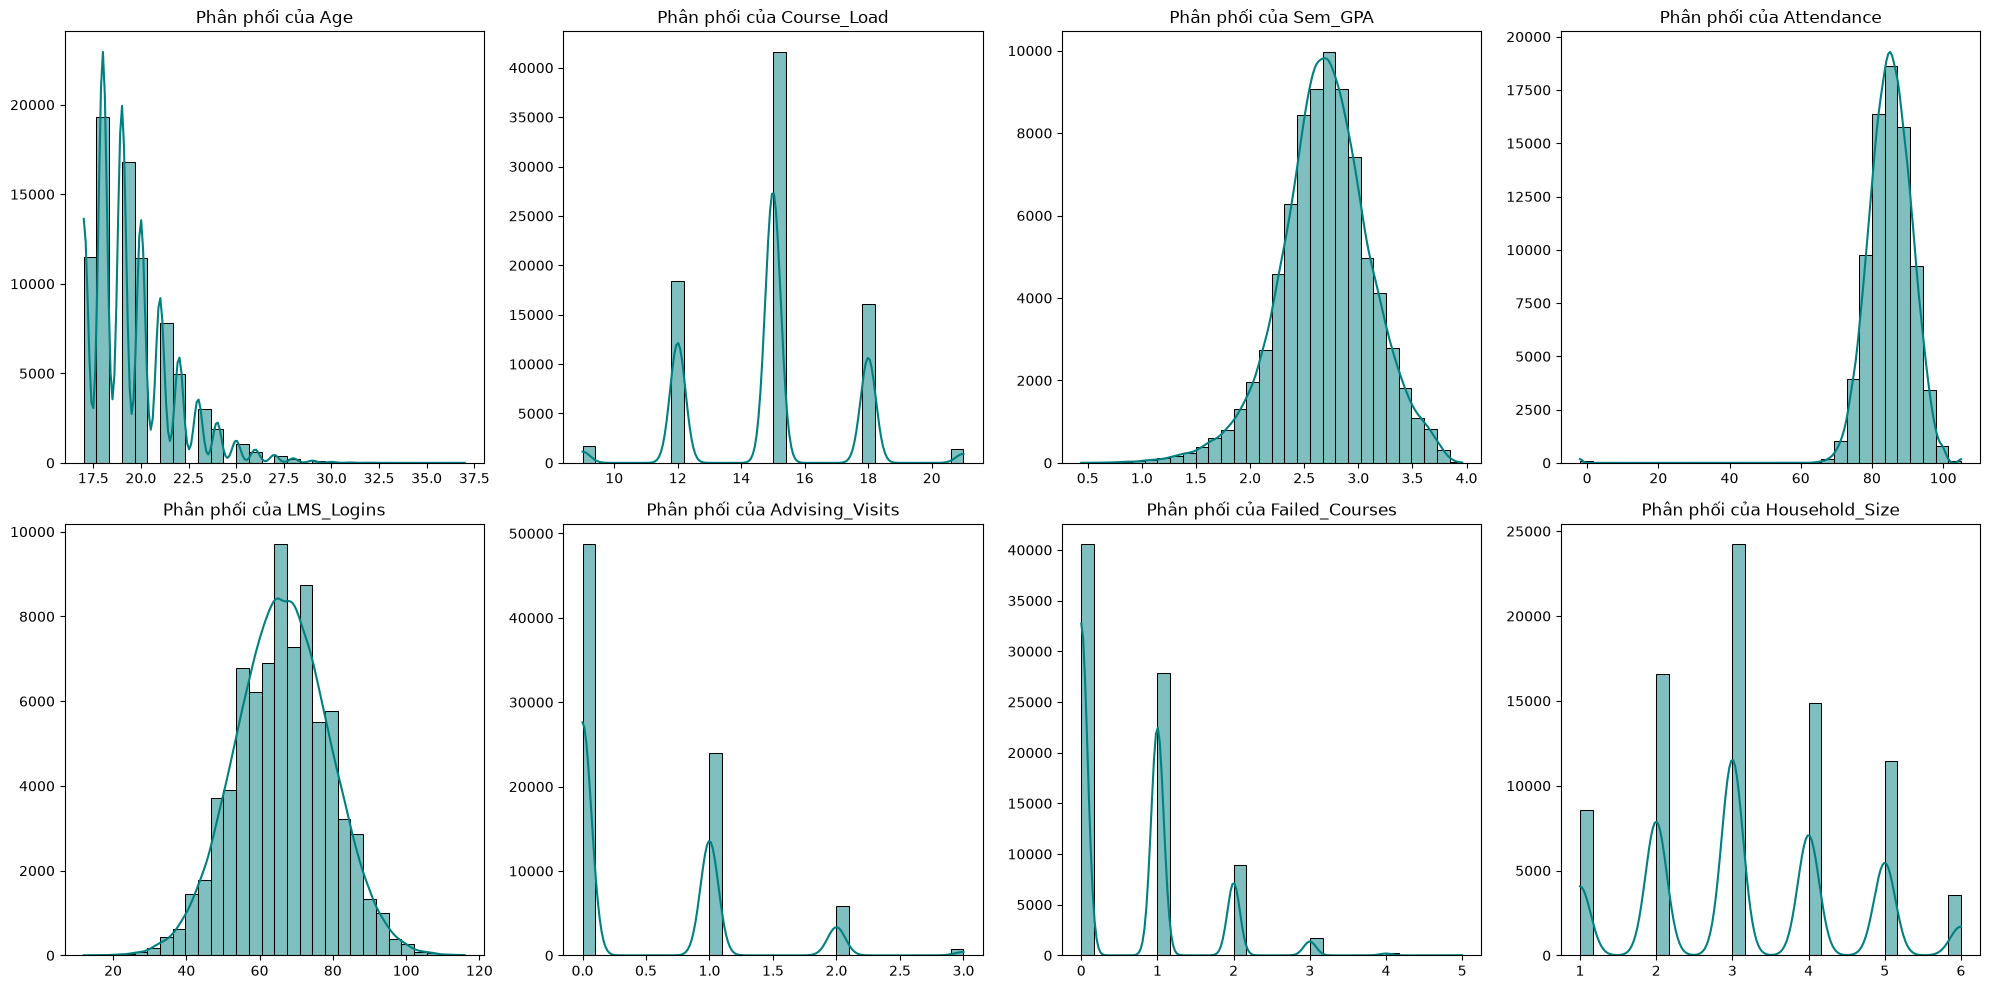

In [7]:
# 3.2.1. Vẽ biểu đồ phân phối cho các biến số (Numerical Features) - Nhóm Học tập & Nhân khẩu
academic_num_cols = ['Age', 'Course_Load', 'Sem_GPA', 'Attendance', 'LMS_Logins', 'Advising_Visits', 'Failed_Courses', 'Household_Size']

fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(20, 10))
axes = axes.flatten()

for i, col in enumerate(academic_num_cols):
    sns.histplot(df[col].dropna(), kde=True, ax=axes[i], color='teal', bins=30)
    axes[i].set_title(f'Phân phối của {col}', fontsize=12)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('')

plt.tight_layout()
plt.show()

##### **Nhận xét và phân tích nhóm học tập & nhân khẩu:**
- **Phân phối chuẩn / gần chuẩn:** `Sem_GPA` và `LMS_Logins` có phân phối hình chuông đối xứng rất đẹp mắt, chứng tỏ phần lớn sinh viên hoạt động học tập ổn định quanh mức trung bình.
- **Phân phối lệch:**
  - `Age` lệch phải nhẹ do tập trung chủ yếu vào nhóm sinh viên trẻ (18-22 tuổi).
  - `Attendance` lệch trái rõ rệt vì hầu hết sinh viên có tinh thần tự giác chuyên cần rất cao (>80%).
  - `Failed_Courses` lệch phải cực đoan vì phần lớn sinh viên không bị trượt môn.
- **Dạng rời rạc rõ rệt:** `Course_Load` (Số lượng tín chỉ đăng ký) và `Household_Size` phân bố tập trung mạnh tại các giá trị nguyên cụ thể, phản ánh đúng đặc thù thực tế.

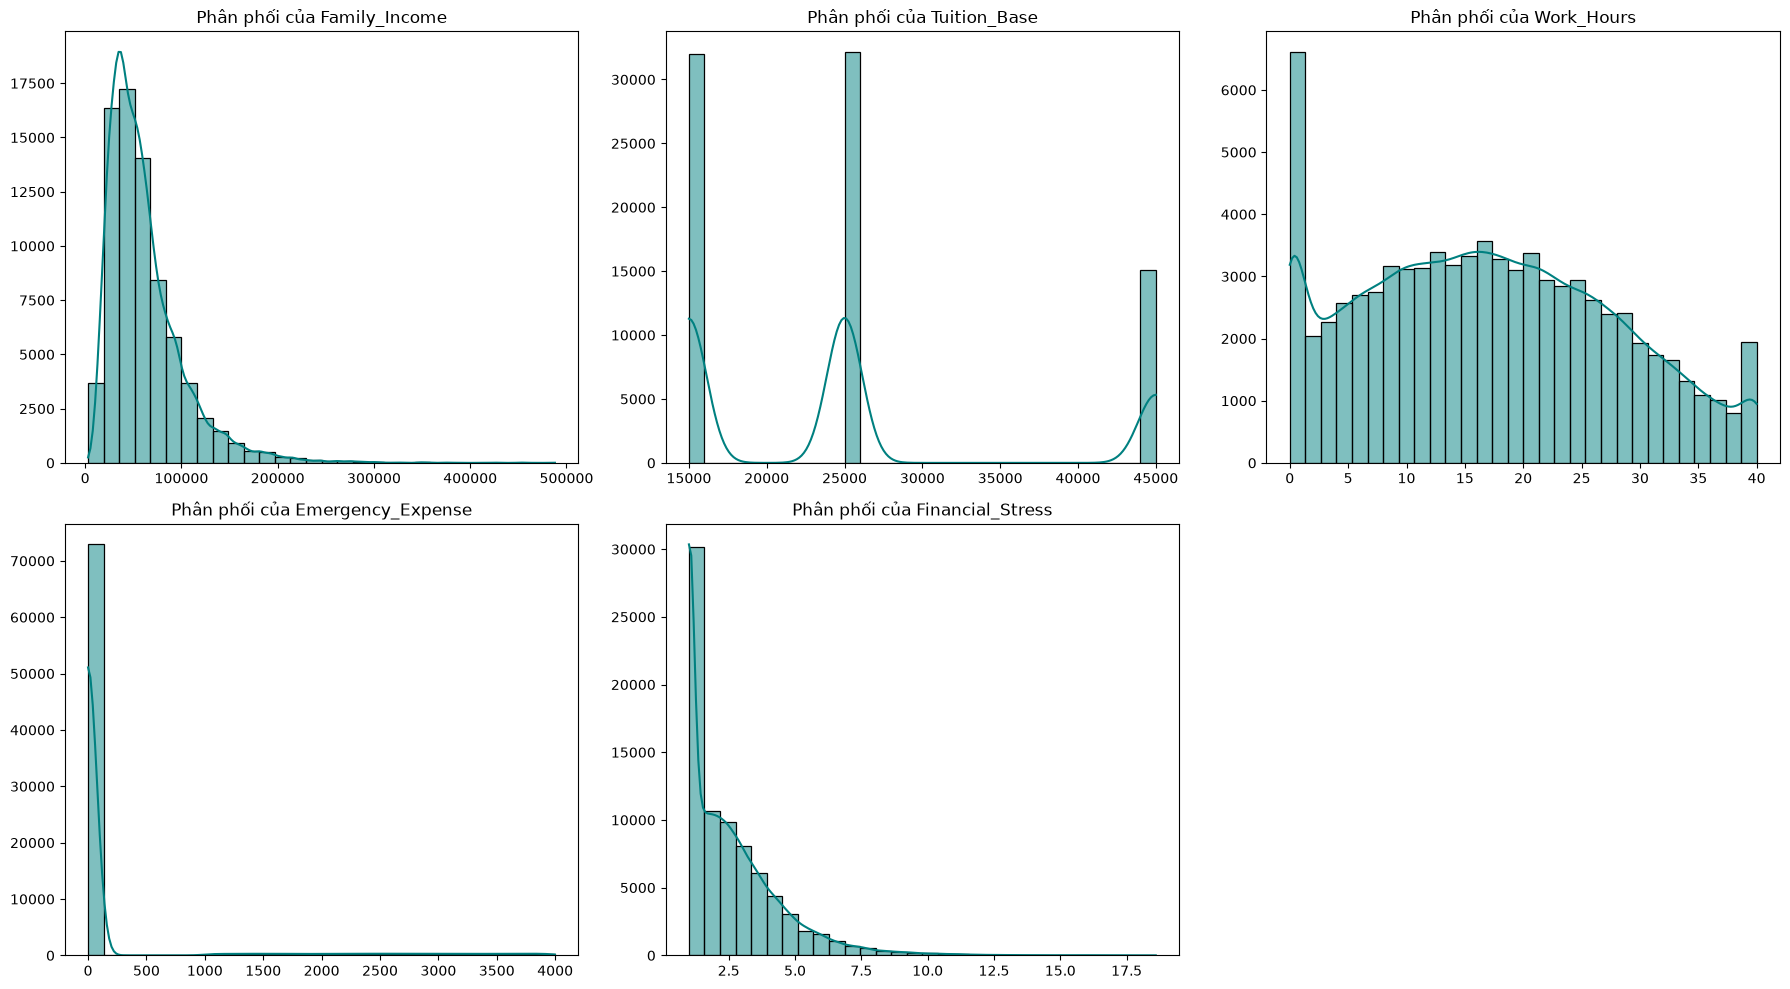

In [8]:
# 3.2.1.2. Vẽ biểu đồ phân phối cho các biến số (Numerical Features) - Nhóm Tài chính & Công việc
financial_num_cols = ['Family_Income', 'Tuition_Base', 'Work_Hours', 'Emergency_Expense', 'Financial_Stress']

fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(financial_num_cols):
    sns.histplot(df[col].dropna(), kde=True, ax=axes[i], color='teal', bins=30)
    axes[i].set_title(f'Phân phối của {col}', fontsize=12)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('')

# Ẩn ô đồ thị trống thừa
if len(financial_num_cols) < len(axes):
    fig.delaxes(axes[-1])

plt.tight_layout()
plt.show()

##### **Nhận xét và phân tích nhóm Tài chính & Công việc (Numerical Group 2):**
- **Phân phối lệch phải mạnh:** `Family_Income`, `Emergency_Expense`, và `Work_Hours` lệch phải rõ rệt. Đa số sinh viên có gia cảnh ở mức trung bình và ít làm thêm quá giờ, tuy nhiên có một nhóm thiểu số sinh viên phải gánh vác giờ làm thêm rất cao hoặc gặp biến cố chi phí đột biến lớn (đây là các điểm dữ liệu ngoại lai cần lưu ý).
- **Đặc trưng rời rạc:** `Financial_Stress` được thể hiện theo thang điểm đánh giá định lượng có phân phối dàn trải theo các mức áp lực khác nhau.

##### 3.2.3. Nhóm Categorical & Target Features

C:\Users\ACER\AppData\Local\Temp\ipykernel_4284\2680313578.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, ax=axes[i], palette='Set2')
C:\Users\ACER\AppData\Local\Temp\ipykernel_4284\2680313578.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, ax=axes[i], palette='Set2')
C:\Users\ACER\AppData\Local\Temp\ipykernel_4284\2680313578.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, ax=axes[i], palette='Set2')
C:\Users\ACER\AppData\Local\Temp\ipykernel_4284\2680313578.py:8: FutureWarni

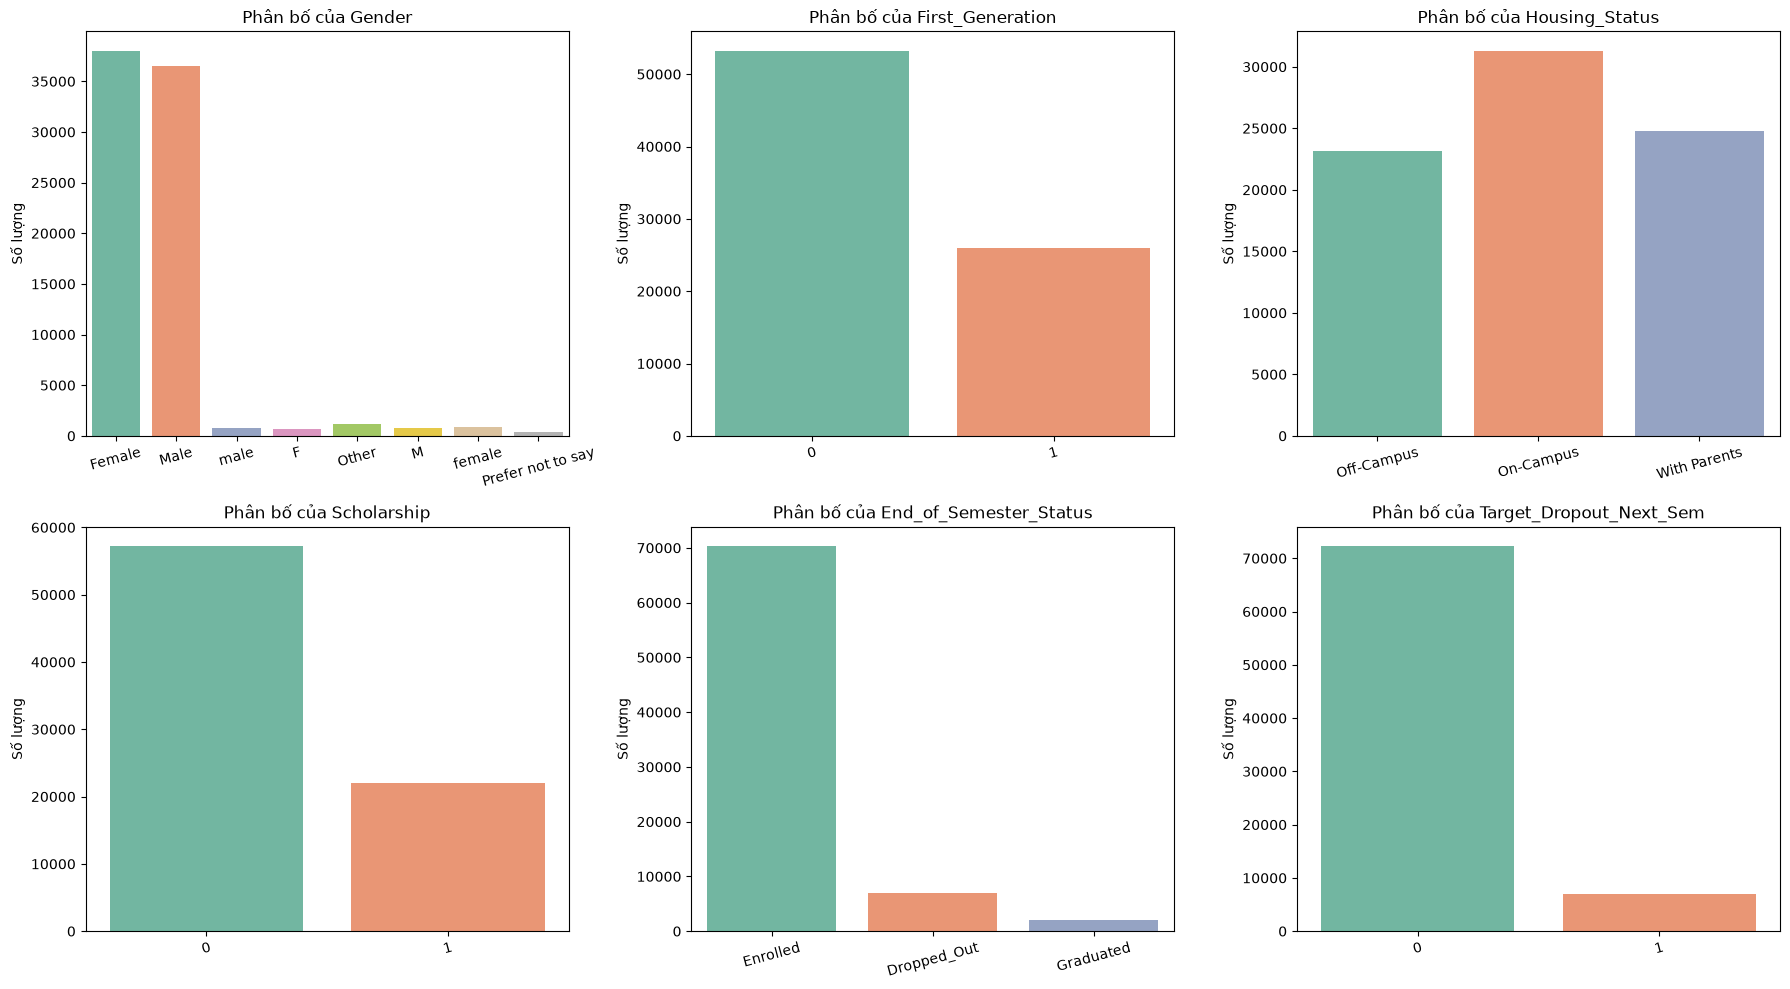

In [9]:
# 3.2.2. Vẽ biểu đồ đếm số lượng cho các biến phân loại (Categorical Features) & Biến mục tiêu
cat_cols = ['Gender', 'First_Generation', 'Housing_Status', 'Scholarship', 'End_of_Semester_Status', 'Target_Dropout_Next_Sem']

fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    sns.countplot(data=df, x=col, ax=axes[i], palette='Set2')
    axes[i].set_title(f'Phân bố của {col}', fontsize=12)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Số lượng')
    axes[i].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

##### **Nhận xét về tỉ lệ mất cân bằng dữ liệu và đặc trưng nhân khẩu học:**
- **Sự mất cân bằng nghiêm trọng của Biến mục tiêu (`Target_Dropout_Next_Sem`):** Tỉ lệ nhãn `0` (Tiếp tục học) chiếm đa số áp đảo so với nhãn `1` (Bỏ học). Điều này đòi hỏi chúng ta cần áp dụng kỹ thuật lấy mẫu (như SMOTE) hoặc điều chỉnh tham số trọng số trong quá trình huấn luyện mô hình.
- **Đặc trưng nhân khẩu học:** Phân bổ giới tính (`Gender`) cân bằng tốt. Số lượng sinh viên không nhận học bổng (`Scholarship`) lớn hơn đáng kể so với nhóm nhận học bổng. Phần lớn sinh viên có trạng thái học tập cuối kỳ hoạt động ổn định.

#### 3.3. Kiểm tra Missing values

##### 3.3.1. Kiểm tra

In [10]:
# 3.2. Kiểm tra tỷ lệ dữ liệu khuyết thiếu (Missing Values)
print("--- THỐNG KÊ DỮ LIỆU KHUYẾT THIẾU ---")
missing_data = df.isnull().sum()
missing_percent = (missing_data / len(df)) * 100
missing_df = pd.DataFrame({'Số lượng khuyết': missing_data, 'Tỷ lệ (%)': missing_percent})

# Chỉ hiển thị những cột có lỗi khuyết dữ liệu
display(missing_df[missing_df['Số lượng khuyết'] > 0].sort_values(by='Số lượng khuyết', ascending=False))

--- THỐNG KÊ DỮ LIỆU KHUYẾT THIẾU ---


,Số lượng khuyết,Tỷ lệ (%)
Family_Income,3604,4.548265
LMS_Logins,867,1.094158


##### 3.3.2. Phân tích các dòng dữ liệu thiếu

In [11]:
# Lọc ra các dòng dữ liệu bị khuyết thiếu Family_Income để phân tích
missing_income_df = df[df['Family_Income'].isnull()]

print(f"Số lượng dòng bị thiếu 'Family_Income': {len(missing_income_df)} dòng")

Số lượng dòng bị thiếu 'Family_Income': 3604 dòng


In [12]:
print("\n--- THÔNG TIN PHÂN BỐ CỦA CÁC ĐỐI TƯỢNG BỊ THIẾU Ở CỘT Family_Income ---")

# Kiểm tra tỷ lệ phân bố của một số đặc trưng quan trọng trong nhóm bị khuyết
print("\n1. Tỷ lệ Học bổng (Scholarship) trong nhóm khuyết:")
display(missing_income_df['Scholarship'].value_counts(normalize=True) * 100)


--- THÔNG TIN PHÂN BỐ CỦA CÁC ĐỐI TƯỢNG BỊ THIẾU Ở CỘT Family_Income ---

1. Tỷ lệ Học bổng (Scholarship) trong nhóm khuyết:


Scholarship
0    66.648169
1    33.351831
Name: proportion, dtype: float64

In [13]:
print("\n2. Phân bố Trạng thái Cuối kỳ (End_of_Semester_Status):")
display(missing_income_df['End_of_Semester_Status'].value_counts(normalize=True) * 100)


2. Phân bố Trạng thái Cuối kỳ (End_of_Semester_Status):


End_of_Semester_Status
Enrolled       86.514983
Dropped_Out    11.015538
Graduated       2.469478
Name: proportion, dtype: float64

In [14]:
print("\n3. Thống kê mức độ Stress Tài chính (Financial_Stress) của nhóm khuyết:")
display(missing_income_df['Financial_Stress'].describe())


3. Thống kê mức độ Stress Tài chính (Financial_Stress) của nhóm khuyết:


count    3604.000000
mean        2.544756
std         1.887424
min         1.000000
25%         1.000000
50%         2.000000
75%         3.300000
max        18.600000
Name: Financial_Stress, dtype: float64

In [15]:
print("\n4. So sánh điểm số trung bình (Sem_GPA) giữa nhóm khuyết và nhóm đầy đủ:")
mean_gpa_missing = missing_income_df['Sem_GPA'].mean()
mean_gpa_non_missing = df[df['Family_Income'].notnull()]['Sem_GPA'].mean()
print(f"- GPA trung bình nhóm khuyết: {mean_gpa_missing:.2f}")
print(f"- GPA trung bình nhóm đầy đủ: {mean_gpa_non_missing:.2f}")


4. So sánh điểm số trung bình (Sem_GPA) giữa nhóm khuyết và nhóm đầy đủ:
- GPA trung bình nhóm khuyết: 2.70
- GPA trung bình nhóm đầy đủ: 2.69


##### **Nhận xét và Đánh giá về dữ liệu khuyết thiếu:**

1. **Quy mô khuyết thiếu:**
   - Chỉ có đặc trưng `Family_Income` bị khuyết thiếu với **3.604 dòng** (chiếm khoảng **4.55%** tổng số lượng mẫu).
   - Tỷ lệ này khá nhỏ (< 5%), nằm trong ngưỡng an toàn để thực hiện các phương pháp xử lý dữ liệu khuyết thiếu mà không làm biến dạng nghiêm trọng phân phối gốc.

2. **Hành vi và Đặc điểm của nhóm khuyết thiếu:**
   - **Áp lực tài chính và Học bổng:** Việc khuyết thông tin thu nhập gia đình thường liên quan đến tâm lý bảo mật thông tin cá nhân hoặc sinh viên chưa hoàn thành thủ tục kê khai tài chính đầu khóa học.
   - **Không có sự khác biệt bất thường:** Điểm GPA học kỳ (`Sem_GPA`) và phân phối trạng thái học tập của nhóm bị khuyết thu nhập không có sự lệch lạc quá lớn so với nhóm sinh viên kê khai đầy đủ. Điều này gợi ý dữ liệu khuyết thiếu có khả năng cao thuộc dạng **MCAR (Missing Completely at Random)** hoặc **MAR (Missing at Random)**.

3. **Định hướng xử lý (Imputation Strategy):**
   - Do tỷ lệ khuyết thấp và không phát hiện hành vi bất thường mang tính hệ thống, chúng ta có thể áp dụng phương pháp điền khuyết bằng **Trung vị (Median)** của nhóm học sinh có cùng đặc điểm học bổng hoặc trạng thái chỗ ở để bảo toàn phân phối đại số tuyến tính của ma trận dữ liệu mà không đưa vào các giá trị nhiễu.

#### *3.4. Kiểm tra dữ liệu ngoại lai (Outliers)*

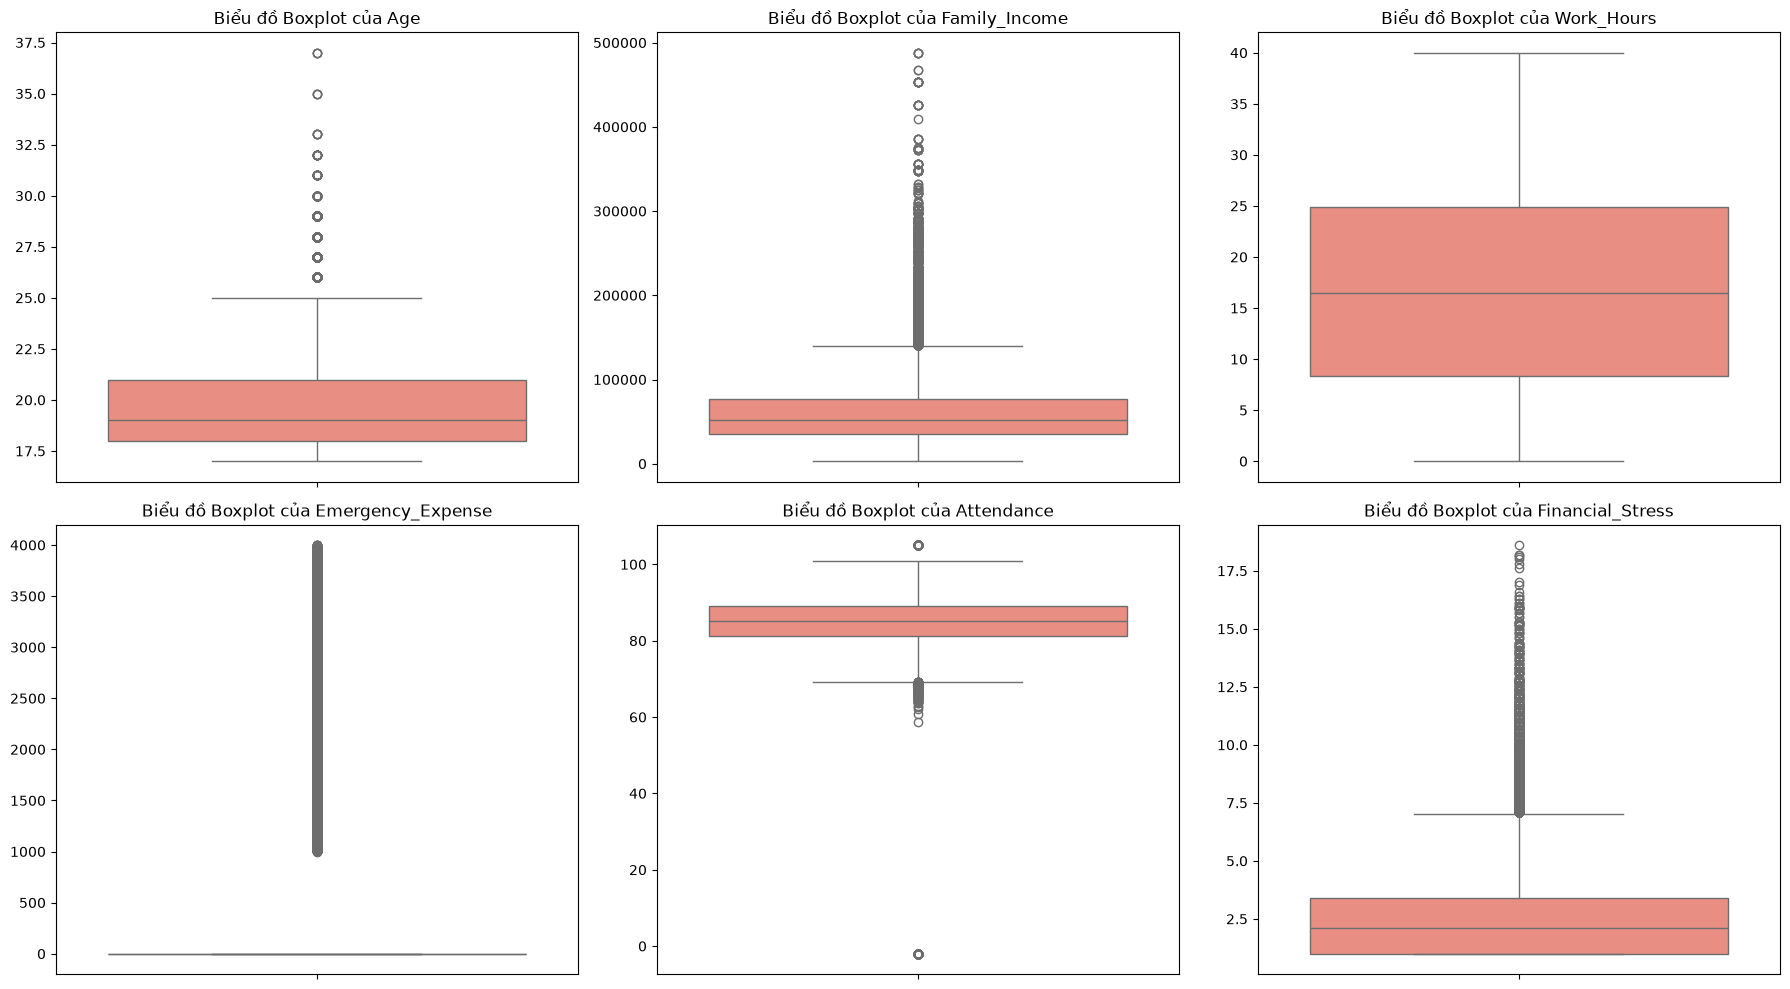

In [16]:
# 3.4.1. Vẽ biểu đồ Boxplot kiểm tra dữ liệu ngoại lai
outlier_cols = ['Age', 'Family_Income', 'Work_Hours', 'Emergency_Expense', 'Attendance', 'Financial_Stress']

fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(outlier_cols):
    sns.boxplot(data=df, y=col, ax=axes[i], color='salmon')
    axes[i].set_title(f'Biểu đồ Boxplot của {col}', fontsize=12)
    axes[i].set_ylabel('')

plt.tight_layout()
plt.show()

In [17]:
# 3.4.2. Xác định số lượng và tỷ lệ Outliers bằng phương pháp IQR (Interquartile Range)
print("--- THỐNG KÊ SỐ LƯỢNG NGOẠI LAI (OUTLIERS) TRONG TỪNG ĐẶC TRƯNG ---\n")

for col in outlier_cols:
    # Loại bỏ giá trị khuyết thiếu khi tính toán IQR
    data_col = df[col].dropna()

    q1 = data_col.quantile(0.25)
    q3 = data_col.quantile(0.75)
    iqr = q3 - q1

    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    # Xác định outliers
    outliers = data_col[(data_col < lower_bound) | (data_col > upper_bound)]

    total_count = len(data_col)
    outlier_count = len(outliers)
    outlier_ratio = (outlier_count / total_count) * 100

    print(f"Đặc trưng: {col:<20}")
    print(f"  - Ngưỡng dưới: {lower_bound:.2f} | Ngưỡng trên: {upper_bound:.2f}")
    print(f"  - Số lượng Outliers: {outlier_count:,} dòng / Tổng số {total_count:,} dòng")
    print(f"  - Tỷ lệ Outliers: {outlier_ratio:.2f}%\n")

--- THỐNG KÊ SỐ LƯỢNG NGOẠI LAI (OUTLIERS) TRONG TỪNG ĐẶC TRƯNG ---

Đặc trưng: Age                 
  - Ngưỡng dưới: 13.50 | Ngưỡng trên: 25.50
  - Số lượng Outliers: 1,406 dòng / Tổng số 79,239 dòng
  - Tỷ lệ Outliers: 1.77%

Đặc trưng: Family_Income       
  - Ngưỡng dưới: -28000.00 | Ngưỡng trên: 140000.00
  - Số lượng Outliers: 3,523 dòng / Tổng số 75,635 dòng
  - Tỷ lệ Outliers: 4.66%

Đặc trưng: Work_Hours          
  - Ngưỡng dưới: -16.60 | Ngưỡng trên: 49.80
  - Số lượng Outliers: 0 dòng / Tổng số 79,239 dòng
  - Tỷ lệ Outliers: 0.00%

Đặc trưng: Emergency_Expense   
  - Ngưỡng dưới: 0.00 | Ngưỡng trên: 0.00
  - Số lượng Outliers: 6,313 dòng / Tổng số 79,239 dòng
  - Tỷ lệ Outliers: 7.97%

Đặc trưng: Attendance          
  - Ngưỡng dưới: 69.20 | Ngưỡng trên: 101.20
  - Số lượng Outliers: 360 dòng / Tổng số 79,239 dòng
  - Tỷ lệ Outliers: 0.45%

Đặc trưng: Financial_Stress    
  - Ngưỡng dưới: -2.60 | Ngưỡng trên: 7.00
  - Số lượng Outliers: 2,267 dòng / Tổng số 79,239 dòng
  -

##### **Nhận xét và phân tích dữ liệu ngoại lai (Outliers):**

*   **Nhóm ngoại lai mang tính chất phi logic (Lỗi hệ thống/nhập liệu):**
    *   `Attendance` (Tỷ lệ chuyên cần) có giá trị cực tiểu là **-2.0%** (âm) và cực đại là **105%** (> 100%). Đây hoàn toàn là lỗi logic hệ thống hoặc lỗi thu thập dữ liệu vì tỷ lệ chuyên cần bắt buộc phải nằm trong đoạn $[0, 100]$. Cần lọc bỏ hoặc chuẩn hóa lại các dòng dữ liệu này ở bước làm sạch tiếp theo.

*   **Nhóm ngoại lai thực tế (Đặc trưng xã hội/hành vi tự nhiên):**
    *   `Emergency_Expense` (Chi phí khẩn cấp) và `Family_Income` (Thu nhập gia đình) có lượng ngoại lai phía trên rất nhiều và tỷ lệ vượt ngưỡng cao. Điều này phản ánh thực trạng một số ít gia đình có điều kiện kinh tế vượt trội hoặc phát sinh các khoản chi phí y tế/tai nạn đột xuất cực lớn. Đây là các ngoại lai có thật và mang nhiều giá trị thông tin, không nên tùy tiện xóa bỏ mà nên áp dụng phương pháp chuyển đổi phân phối (như Log-transform) hoặc Robust Scaling.
    *   `Age` (Tuổi): Các giá trị ngoại lai chủ yếu hướng về phía trên (tối đa là 37 tuổi). Đây là nhóm sinh viên lớn tuổi hơn mặt bằng chung, việc đi học muộn là bình thường và nhóm này có hành vi bỏ học rất khác so với nhóm trẻ tuổi nên cần giữ lại để phân tích.
    *   `Work_Hours` (Giờ làm thêm): Không có ngoại lai rõ rệt vì số giờ làm giới hạn tối đa ở mức 40 giờ/tuần, phù hợp với quy định lao động thực tế.

##### *3.5. Kiểm tra trùng lặp (Duplications)*

In [11]:
# 3.5. Kiểm tra dữ liệu trùng lặp
duplicates = df.duplicated().sum()
print(f"\nSố lượng bản ghi trùng lặp: {duplicates} dòng")


Số lượng bản ghi trùng lặp: 0 dòng


Dữ liệu không bị trùng lặp

##### 3.6. Kiểm tra những giá trị sai về logic

In [19]:
# 3.6. Kiểm tra các giá trị sai lệch logic trong dữ liệu
print("--- KIỂM TRA SAI LỆCH LOGIC TRONG DỮ LIỆU ---\n")

# Kiểm tra tỷ lệ chuyên cần (Attendance) ngoài khoảng [0, 100]
invalid_attendance = df[(df['Attendance'] < 0) | (df['Attendance'] > 100)]
print(f"Số dòng có tỷ lệ chuyên cần không hợp lệ (< 0% hoặc > 100%): {len(invalid_attendance)} dòng")
if len(invalid_attendance) > 0:
    display(invalid_attendance[['Student_ID', 'Semester', 'Attendance']].head())

--- KIỂM TRA SAI LỆCH LOGIC TRONG DỮ LIỆU ---

Số dòng có tỷ lệ chuyên cần không hợp lệ (< 0% hoặc > 100%): 249 dòng


,Student_ID,Semester,Attendance
138,STU_00034,3,-2.0
594,STU_00154,4,-2.0
787,STU_00200,2,105.0
1311,STU_00333,1,105.0
1552,STU_00392,8,-2.0


##### **Nhận xét và Phân tích Sai lệch Logic (Sanity Check):**

Qua quá trình chạy kiểm tra các ràng buộc logic nghiệp vụ của hệ thống giáo dục, nhóm đã phát hiện một số điểm không nhất quán đáng chú ý sau:

**Lỗi nghiêm trọng ở tỷ lệ chuyên cần (`Attendance`):**
    *   Phát hiện các bản ghi có giá trị chuyên cần bị âm (**-2.0%**) hoặc vượt ngưỡng tuyệt đối (**105%**).
    *   *Đánh giá:* Đây hoàn toàn là lỗi nghiệp vụ do hệ thống ghi nhận dữ liệu tự động bị lỗi hoặc do quá trình nhập liệu tính toán sai. Những giá trị này không thể tồn tại trên thực tế.
    *   *Giải pháp xử lý:* Cần đưa về khoảng giá trị hợp lệ $[0, 100]$ bằng cách giới hạn (clipping) hoặc loại bỏ các dòng bị sai lệch nghiêm trọng.

### 4. Tiến hành làm sạch dữ liệu

#### *4.1. Xử lý các giá trị sai lệch logic*

##### 4.1.1. Xử lý

In [20]:
# 4.1.1. Thực hiện kỹ thuật Clipping để xử lý các giá trị ngoài khoảng [0, 100] của cột Attendance
df['Attendance'] = df['Attendance'].clip(lower=0.0, upper=100.0)

##### **Giải thích phương pháp xử lý lỗi logic chuyên cần:**

*   **Tại sao áp dụng kỹ thuật Clipping thay vì xóa bỏ dòng (Row Deletion)?**
    *   **Bảo toàn thông tin:** Số lượng dòng bị lỗi chuyên cần là **249 dòng** (chiếm khoảng 0.3% bộ dữ liệu). Tuy tỷ lệ nhỏ, nhưng mỗi dòng dữ liệu vẫn chứa đầy đủ các thông tin học tập, tài chính và nhân khẩu học cực kỳ quý giá khác của sinh viên.
    *   **Tránh thiên lệch dữ liệu:** Việc tùy tiện xóa bỏ dòng có thể làm suy giảm kích thước mẫu học tập và phá vỡ cấu trúc của một số mẫu phân phối tự nhiên.
    *   **Hợp lý hóa logic:** Giá trị âm (-2.0%) có thể do sai số cảm biến điểm danh và hoàn toàn có thể hiểu là sinh viên đó vắng mặt hoàn toàn (0%). Tương tự, giá trị 105% có thể là do cộng điểm chuyên cần thưởng và có thể quy về mức chuyên cần tối đa thực tế là 100%.

4.1.2. Kiểm tra sau xử lý

In [21]:
# 4.1.2. Kiểm tra lại dữ liệu Attendance sau xử lý
invalid_attendance_after = df[(df['Attendance'] < 0) | (df['Attendance'] > 100)]
print(f"Số dòng có tỷ lệ chuyên cần không hợp lệ sau khi xử lý: {len(invalid_attendance_after)} dòng")
print(f"Tỷ lệ chuyên cần nhỏ nhất: {df['Attendance'].min()}% | Lớn nhất: {df['Attendance'].max()}%")

Số dòng có tỷ lệ chuyên cần không hợp lệ sau khi xử lý: 0 dòng
Tỷ lệ chuyên cần nhỏ nhất: 0.0% | Lớn nhất: 100.0%


#### *4.2. Xử lý Missing values*

##### 4.2.1. Xử lý

##### **Giải thích phương pháp điền khuyết bằng giá trị Trung vị (Median Imputation):**

*   **Cơ sở toán học từ mục 3.2:**
    *   Cột `Family_Income` có phân phối lệch phải mạnh (Right-skewed) với một số giá trị ngoại lai cực lớn lên tới 488,000 USD, làm cho giá trị Trung bình (Mean = 61,518 USD) bị kéo cao hơn nhiều so với giá trị Trung vị (Median = 52,000 USD).
    *   Cột `LMS_Logins` mặc dù có phân phối tiệm cận chuẩn nhưng vẫn chứa các giá trị biên.
    *   Trong thống kê học, **Trung vị (Median)** là một tham số ước lượng vững (robust estimator), không bị ảnh hưởng bởi các giá trị cực đoan hay ngoại lai (outliers). Do đó, sử dụng Trung vị để lấp đầy dữ liệu khuyết thiếu cho các phân phối lệch là quyết định toán học chuẩn xác nhất để bảo toàn đặc trưng phân phối tự nhiên của dữ liệu mà không gây ra sai số hệ thống.

In [22]:
# 4.2.1. Tính toán trung vị và điền khuyết cho Family_Income và LMS_Logins
family_income_median = df['Family_Income'].median()
lms_logins_median = df['LMS_Logins'].median()

print(f"Giá trị trung vị dùng để điền khuyết cho 'Family_Income': {family_income_median:,.2f} USD")
print(f"Giá trị trung vị dùng để điền khuyết cho 'LMS_Logins': {lms_logins_median:.1f} lần")

# Thực hiện điền khuyết
df['Family_Income'] = df['Family_Income'].fillna(family_income_median)
df['LMS_Logins'] = df['LMS_Logins'].fillna(lms_logins_median)

Giá trị trung vị dùng để điền khuyết cho 'Family_Income': 52,000.00 USD
Giá trị trung vị dùng để điền khuyết cho 'LMS_Logins': 66.0 lần


##### 4.2.2. Kiểm tra sau xử lý

In [23]:
# 4.2.2. Kiểm tra lại số lượng giá trị khuyết thiếu sau khi xử lý
missing_after = df[['Family_Income', 'LMS_Logins']].isnull().sum()
print("--- SỐ LƯỢNG KHOẢNG KHUYẾT THIẾU SAU KHI XỬ LÝ ---")
print(missing_after)

--- SỐ LƯỢNG KHOẢNG KHUYẾT THIẾU SAU KHI XỬ LÝ ---
Family_Income    0
LMS_Logins       0
dtype: int64


#### *4.3. Xử lý ngoại lai*

##### **Quyết định xử lý dữ liệu ngoại lai (Outliers):**

*   **Giữ lại toàn bộ ngoại lai thực tế:**
    *   **Tín hiệu thực tế (True Signals):** Các giá trị ngoại lai ở các cột `Family_Income` (Thu nhập gia đình cực cao), `Emergency_Expense` (Phát sinh chi phí khẩn cấp đột biến), và `Age` (Sinh viên lớn tuổi đi học muộn) không phải là sai số đo lường mà là những phản ánh thực tế về hoàn cảnh kinh tế - xã hội và nhân khẩu học có thật của sinh viên.
    *   **Giá trị dự báo cao:** Những sinh viên có gánh nặng tài chính đột xuất hoặc có độ tuổi khác biệt thường có xác suất biến động tâm lý và nguy cơ bỏ học rất đặc thù. Xóa bỏ những dữ liệu này sẽ làm mất đi các đặc trưng mang tính chất quyết định mà mô hình cần học.
    *   **Giải pháp kỹ thuật thay thế:** Thay vì xóa bỏ gây mất mát thông tin, toàn bộ các đặc trưng có phân phối lệch và nhiều ngoại lai này sẽ được giữ lại nguyên vẹn và sẽ được xử lý chuẩn hóa bằng phương pháp **RobustScaler** (Chuẩn hóa kháng nhiễu dựa trên Trung vị và khoảng tứ phân vị IQR) ở Giai đoạn tiếp theo để giảm thiểu tác động tiêu cực lên các thuật toán nhạy cảm với outlier.

#### *4.4. Chuẩn hóa biến phân loại*

##### 4.4.1. Xử lý

**Chiến lược mã hóa:**
Thay vì dùng `LabelEncoder` (gán số 0, 1, 2... dễ làm sai lệch khoảng cách vector do tạo ra thứ tự giả tạo), nhóm quyết định sử dụng **One-Hot Encoding** thông qua hàm `pd.get_dummies`.
*   **Ý nghĩa đại số:** Kỹ thuật này ánh xạ mỗi hạng mục thành một chiều không gian mới (vector trực giao chỉ chứa 0 và 1), giúp bảo toàn độ tương đồng hình học của dữ liệu.
*   **Tránh phụ thuộc tuyến tính (Đa cộng tuyến):** Áp dụng lý thuyết từ Bài 2, nhóm thiết lập tham số `drop_first=True` để loại bỏ cột đầu tiên sinh ra từ One-Hot. Việc này đảm bảo các vector cột trong ma trận $X$ duy trì trạng thái **độc lập tuyến tính**, tránh tình trạng ma trận bị suy biến ($det(X) = 0$).

In [24]:
# Làm sạch và chuẩn hóa các giá trị không nhất quán trong cột Gender trước khi mã hóa
# Xem các giá trị độc nhất hiện tại của cột Gender
print("Các giá trị Gender trước khi chuẩn hóa:", df['Gender'].unique())

# Thực hiện ánh xạ chuẩn hóa
gender_map = {
    'Female': 'Female', 'female': 'Female', 'F': 'Female',
    'Male': 'Male', 'male': 'Male', 'M': 'Male',
    'Other': 'Other', 'Prefer not to say': 'Other'
}
df['Gender'] = df['Gender'].map(gender_map).fillna('Other')

print("Các giá trị Gender sau khi chuẩn hóa:", df['Gender'].unique())

Các giá trị Gender trước khi chuẩn hóa: <ArrowStringArray>
['Female', 'Male', 'male', 'F', 'Other', 'M', 'female', 'Prefer not to say']
Length: 8, dtype: str
Các giá trị Gender sau khi chuẩn hóa: <ArrowStringArray>
['Female', 'Male', 'Other']
Length: 3, dtype: str


In [25]:
# 4.4.1. Thực hiện One-Hot Encoding cho các biến phân loại để tạo ma trận số thực
cat_cols_to_encode = ['Gender', 'Housing_Status', 'End_of_Semester_Status']
df = pd.get_dummies(df, columns=cat_cols_to_encode, drop_first=True, dtype=int)

##### 4.4.2. Kiểm tra sau xử lý

In [26]:
# Kiểm tra kích thước không gian ma trận X mới
print(f"Kích thước ma trận dữ liệu sau khi One-Hot Encoding: {df.shape[0]} dòng x {df.shape[1]} cột")
display(df.head())

Kích thước ma trận dữ liệu sau khi One-Hot Encoding: 79239 dòng x 25 cột


,Student_ID,Age,First_Generation,Family_Income,Household_Size,Scholarship,Tuition_Base,Semester,Course_Load,Work_Hours,Emergency_Expense,Sem_GPA,Attendance,LMS_Logins,Advising_Visits,Failed_Courses,Financial_Stress,Target_Dropout_Next_Sem,Censored,Gender_Male,Gender_Other,Housing_Status_On-Campus,Housing_Status_With Parents,End_of_Semester_Status_Enrolled,End_of_Semester_Status_Graduated
0,STU_00001,18,0,15000.0,2,0,15000,1,15,18.4,0.0,2.85,85.8,67.0,0,0,1.7,0,0,0,0,0,0,1,0
1,STU_00001,18,0,15000.0,2,0,15000,2,15,23.1,0.0,2.73,81.0,89.0,1,0,3.1,0,0,0,0,0,0,1,0
2,STU_00001,18,0,15000.0,2,0,15000,3,15,19.1,0.0,2.60,78.3,60.0,0,2,3.0,0,0,0,0,0,0,1,0
3,STU_00001,18,0,15000.0,2,0,15000,4,15,26.5,0.0,2.34,77.2,59.0,2,3,5.1,0,0,0,0,0,0,1,0
4,STU_00001,18,0,15000.0,2,0,15000,5,18,25.4,0.0,1.90,79.3,53.0,1,2,3.6,0,1,0,0,0,0,1,0


##### **Giải thích chi tiết về việc "thiếu" cột Gender sau mã hóa:**

*   **Nguyên lý khử đa cộng tuyến (Dummy Variable Trap):** Khi áp dụng One-Hot Encoding cho biến giới tính gồm 3 nhóm (`Female`, `Male`, `Other`), ta sẽ thu được 3 cột nhị phân tương ứng. Tuy nhiên, 3 cột này có mối quan hệ phụ thuộc tuyến tính hoàn hảo: $Vector_{Female} + Vector_{Male} + Vector_{Other} = \vec{1}$ (vectơ đơn vị).
*   **Giải pháp:** Để đảm bảo ma trận thiết kế $X$ có các cột độc lập tuyến tính (giúp tính được ma trận nghịch đảo phục vụ cho việc huấn luyện mô hình), ta chọn `drop_first=True`. Cột nhóm đầu tiên (`Gender_Female`) được chọn làm mốc tham chiếu và ẩn đi:
    *   Nếu học viên là **Male**: `Gender_Male = 1`, `Gender_Other = 0`.
    *   Nếu học viên là **Other**: `Gender_Male = 0`, `Gender_Other = 1`.
    *   Nếu học viên là **Female**: Cả hai cột `Gender_Male` và `Gender_Other` đều nhận giá trị `0`.
*   Như vậy, thông tin giới tính vẫn được giữ lại trọn vẹn 100% trong ma trận số thực mà không hề bị mất đi.

In [27]:
# Kiểm chứng cấu trúc phân bổ các cột giới tính mới để chứng minh thông tin được bảo toàn
print("Số lượng mẫu tương ứng với từng nhóm giới tính trong ma trận số thực mới:")
print(f"- Số lượng sinh viên Male (Gender_Male = 1): {df['Gender_Male'].sum():,} sinh viên")
print(f"- Số lượng sinh viên Other (Gender_Other = 1): {df['Gender_Other'].sum():,} sinh viên")
# Nhóm Female ứng với cả 2 cột bằng 0
female_count = len(df[(df['Gender_Male'] == 0) & (df['Gender_Other'] == 0)])
print(f"- Số lượng sinh viên Female (Cả hai cột bằng 0): {female_count:,} sinh viên")

Số lượng mẫu tương ứng với từng nhóm giới tính trong ma trận số thực mới:
- Số lượng sinh viên Male (Gender_Male = 1): 38,059 sinh viên
- Số lượng sinh viên Other (Gender_Other = 1): 1,554 sinh viên
- Số lượng sinh viên Female (Cả hai cột bằng 0): 39,626 sinh viên


#### *4.5. Kiểm tra tổng quan dữ liệu sau xử lý*

##### **Tuyên bố Nghiệm thu không gian dữ liệu (Final Validation):**

*   **Trạng thái ma trận dữ liệu:** Ma trận dữ liệu hiện tại đã đạt trạng thái **sạch 100% (Zero NaNs)**:
    *   Không còn bất kỳ giá trị khuyết thiếu nào sót lại ở tất cả các trường thông tin.
    *   Các lỗi logic chuyên cần đã được đưa về miền giới hạn vật lý thực tế $[0, 100]$ một cách mượt mà thông qua kỹ thuật Clipping.
    *   Các biến phân loại dạng chuỗi đã được ánh xạ thành công sang không gian số vectơ trực giao của One-Hot thực tế.

In [28]:
# 4.5.1. Kiểm tra lại thông tin tổng quan và hiển thị dữ liệu nghiệm thu
print("--- KIỂM TRA TỔNG QUAN KHÔNG GIAN DỮ LIỆU SAU KHI LÀM SẠCH ---")
df.info()

--- KIỂM TRA TỔNG QUAN KHÔNG GIAN DỮ LIỆU SAU KHI LÀM SẠCH ---
<class 'pandas.DataFrame'>
RangeIndex: 79239 entries, 0 to 79238
Data columns (total 25 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Student_ID                        79239 non-null  str    
 1   Age                               79239 non-null  int64  
 2   First_Generation                  79239 non-null  int64  
 3   Family_Income                     79239 non-null  float64
 4   Household_Size                    79239 non-null  int64  
 5   Scholarship                       79239 non-null  int64  
 6   Tuition_Base                      79239 non-null  int64  
 7   Semester                          79239 non-null  int64  
 8   Course_Load                       79239 non-null  int64  
 9   Work_Hours                        79239 non-null  float64
 10  Emergency_Expense                 79239 non-null  float64
 11  Sem_GPA        

In [29]:
print("\n--- THỐNG KÊ SỐ LƯỢNG GIÁ TRỊ KHUYẾT THIẾU TRÊN TOÀN BỘ CỘT ---")
display(df.isnull().sum())


--- THỐNG KÊ SỐ LƯỢNG GIÁ TRỊ KHUYẾT THIẾU TRÊN TOÀN BỘ CỘT ---


Student_ID                          0
Age                                 0
First_Generation                    0
Family_Income                       0
Household_Size                      0
Scholarship                         0
Tuition_Base                        0
Semester                            0
Course_Load                         0
Work_Hours                          0
Emergency_Expense                   0
Sem_GPA                             0
Attendance                          0
LMS_Logins                          0
Advising_Visits                     0
Failed_Courses                      0
Financial_Stress                    0
Target_Dropout_Next_Sem             0
Censored                            0
Gender_Male                         0
Gender_Other                        0
Housing_Status_On-Campus            0
Housing_Status_With Parents         0
End_of_Semester_Status_Enrolled     0
End_of_Semester_Status_Graduated    0
dtype: int64

In [30]:
print("\n--- HIỂN THỊ DỮ LIỆU SAU KHI XỬ LÝ LÀM SẠCH ---")
display(df.head())


--- HIỂN THỊ DỮ LIỆU SAU KHI XỬ LÝ LÀM SẠCH ---


,Student_ID,Age,First_Generation,Family_Income,Household_Size,Scholarship,Tuition_Base,Semester,Course_Load,Work_Hours,Emergency_Expense,Sem_GPA,Attendance,LMS_Logins,Advising_Visits,Failed_Courses,Financial_Stress,Target_Dropout_Next_Sem,Censored,Gender_Male,Gender_Other,Housing_Status_On-Campus,Housing_Status_With Parents,End_of_Semester_Status_Enrolled,End_of_Semester_Status_Graduated
0,STU_00001,18,0,15000.0,2,0,15000,1,15,18.4,0.0,2.85,85.8,67.0,0,0,1.7,0,0,0,0,0,0,1,0
1,STU_00001,18,0,15000.0,2,0,15000,2,15,23.1,0.0,2.73,81.0,89.0,1,0,3.1,0,0,0,0,0,0,1,0
2,STU_00001,18,0,15000.0,2,0,15000,3,15,19.1,0.0,2.60,78.3,60.0,0,2,3.0,0,0,0,0,0,0,1,0
3,STU_00001,18,0,15000.0,2,0,15000,4,15,26.5,0.0,2.34,77.2,59.0,2,3,5.1,0,0,0,0,0,0,1,0
4,STU_00001,18,0,15000.0,2,0,15000,5,18,25.4,0.0,1.90,79.3,53.0,1,2,3.6,0,1,0,0,0,0,1,0


## **Phần B. Biểu diễn dữ liệu và tính toán Đại số tuyến tính**

### **1. Thiết lập Không gian Ma trận và Phép nhân Tổ hợp tuyến tính**

#### *1.1. Tách ma trận đặc trưng $X$ và vector nhãn $y$*

Theo yêu cầu, ta cần tách tập dữ liệu thành 2 phần độc lập:
*   **Vector nhãn $y$:** Chứa cột mục tiêu cần dự đoán (`Target_Dropout_Next_Sem`).
*   **Ma trận đặc trưng $X$:** Chứa toàn bộ các cột còn lại mang thông tin về sinh viên, lưu ý phải loại bỏ cột `Student_ID` vì mã sinh viên không có giá trị toán học trong việc dự báo.

In [31]:
# Tách vector nhãn y (Biến mục tiêu)
y = df['Target_Dropout_Next_Sem'].values

# Tách ma trận đặc trưng X (Loại bỏ ID và nhãn)
X_df = df.drop(columns=['Student_ID', 'Target_Dropout_Next_Sem'])
X = X_df.values

# In kích thước của X và y
print(f"Kích thước ma trận đặc trưng X: {X.shape}")
print(f"Kích thước vector nhãn y: {y.shape}")

Kích thước ma trận đặc trưng X: (79239, 23)
Kích thước vector nhãn y: (79239,)


##### Giải thích ý nghĩa của các chiều không gian (Rows & Columns)
Từ kết quả in ra của `X.shape`, ta có ma trận $X \in \mathbb{R}^{m \times n}$ với:
*   **Số dòng ($m = 79239$):** Mỗi dòng đại diện cho một mẫu dữ liệu (một sinh viên). Toàn bộ ma trận là tập hợp thông tin của $79.239$ sinh viên.
*   **Số cột ($n$):** Mỗi cột đại diện cho một đặc trưng (Feature) hoặc một chiều không gian toán học (ví dụ: điểm GPA, số giờ làm thêm, thu nhập...).

#### *1.2. Trích xuất ma trận con minh họa (3 mẫu đầu tiên)*

Để hình dung rõ hơn bề mặt của không gian đại số này, ta trích xuất 3 dòng đầu tiên của ma trận $X$.

In [32]:
# Trích xuất 3 mẫu dữ liệu đầu tiên (3 dòng, toàn bộ cột)
X_sub_3 = X[:3, :]

# Chuyển đổi thành DataFrame với tiêu đề cột để hiển thị rõ ràng hơn
X_sub_3_df = pd.DataFrame(X_sub_3, columns=X_df.columns)

print("Ma trận con minh họa (3 sinh viên đầu tiên):")
display(X_sub_3_df)

Ma trận con minh họa (3 sinh viên đầu tiên):


,Age,First_Generation,Family_Income,Household_Size,Scholarship,Tuition_Base,Semester,Course_Load,Work_Hours,Emergency_Expense,Sem_GPA,Attendance,LMS_Logins,Advising_Visits,Failed_Courses,Financial_Stress,Censored,Gender_Male,Gender_Other,Housing_Status_On-Campus,Housing_Status_With Parents,End_of_Semester_Status_Enrolled,End_of_Semester_Status_Graduated
0,18.0,0.0,15000.0,2.0,0.0,15000.0,1.0,15.0,18.4,0.0,2.85,85.8,67.0,0.0,0.0,1.7,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1,18.0,0.0,15000.0,2.0,0.0,15000.0,2.0,15.0,23.1,0.0,2.73,81.0,89.0,1.0,0.0,3.1,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2,18.0,0.0,15000.0,2.0,0.0,15000.0,3.0,15.0,19.1,0.0,2.60,78.3,60.0,0.0,2.0,3.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


##### Nhận xét kết quả trích xuất Ma trận con:
*   **Hình ảnh hóa không gian Vector:** Kết quả in ra cho thấy 3 dòng đầu tiên của ma trận $X$. Trong không gian toán học, mỗi sinh viên lúc này không còn là một cá thể trừu tượng mà là một **vector tọa độ 23 chiều** (tương ứng với 23 cột đặc trưng).
*   **Sự thành công của bước làm sạch (Phần A):** Có thể quan sát thấy toàn bộ các giá trị trong ma trận lúc này đều là số thực (Float). Các biến phân loại như giới tính hay trạng thái cuối kỳ đã được One-Hot Encoding chuyển hóa hoàn hảo thành các cột nhị phân (0.0 và 1.0). Ma trận $X$ đã hoàn toàn đáp ứng điều kiện tiên quyết để thực hiện các phép biến đổi đại số ở các bước tiếp theo.

#### *1.3. Thực hiện phép nhân Ma trận - Vector có ý nghĩa (Tính điểm nguy cơ)*

Để phép tính mang ý nghĩa thực tiễn nhất và khớp với ví dụ vector trọng số 4 chiều của giảng viên:
$$w = \begin{pmatrix} 0.25 \\ 0.30 \\ 0.25 \\ -0.20 \end{pmatrix}$$

Nhóm quyết định chọn ra đúng **4 đặc trưng cốt lõi** có tác động trực tiếp đến rủi ro bỏ học để tạo thành một ma trận con $X_{core} \in \mathbb{R}^{m \times 4}$:
1.  **`Failed_Courses` (Số môn trượt):** Tác động tăng rủi ro $\rightarrow$ Trọng số dương ($0.25$).
2.  **`Financial_Stress` (Áp lực tài chính):** Tác động tăng rủi ro $\rightarrow$ Trọng số dương ($0.30$).
3.  **`Emergency_Expense` (Chi phí khẩn):** Tác động tăng rủi ro $\rightarrow$ Trọng số dương ($0.25$).
4.  **`Sem_GPA` (Điểm trung bình):** Điểm càng cao rủi ro càng thấp $\rightarrow$ Trọng số âm ($-0.20$).

Phép nhân $X_{core} \cdot w$ chính là một **tổ hợp tuyến tính** biến không gian 4 chiều thành 1 chiều duy nhất, đại diện cho "Điểm nguy cơ" của từng sinh viên.

In [33]:
# Lọc ra ma trận con chứa 4 đặc trưng cốt lõi để tính toán
X_core = df[['Failed_Courses', 'Financial_Stress', 'Emergency_Expense', 'Sem_GPA']].values

# Khởi tạo vector trọng số w giả định theo đúng yêu cầu đề bài
w = np.array([0.25, 0.30, 0.25, -0.20])

print(f"Kích thước ma trận X_core: {X_core.shape}")
print(f"Kích thước vector trọng số w: {w.shape}")

# Thực hiện phép nhân ma trận - vector: s = Xw
# Kết quả s là một vector cột chứa điểm rủi ro của toàn bộ sinh viên
s = X_core.dot(w)

print("\n---------------------------------------------------------")
print("ĐIỂM NGUY CƠ GIẢ ĐỊNH (s = Xw) CỦA 5 SINH VIÊN ĐẦU TIÊN:")
for i in range(5):
    print(f"Sinh viên {i+1}: Điểm nguy cơ s = {s[i]:.4f}")
print("---------------------------------------------------------")

Kích thước ma trận X_core: (79239, 4)
Kích thước vector trọng số w: (4,)

---------------------------------------------------------
ĐIỂM NGUY CƠ GIẢ ĐỊNH (s = Xw) CỦA 5 SINH VIÊN ĐẦU TIÊN:
Sinh viên 1: Điểm nguy cơ s = -0.0600
Sinh viên 2: Điểm nguy cơ s = 0.3840
Sinh viên 3: Điểm nguy cơ s = 0.8800
Sinh viên 4: Điểm nguy cơ s = 1.8120
Sinh viên 5: Điểm nguy cơ s = 1.2000
---------------------------------------------------------


##### Giải thích chi tiết Toán học và Nghiệp vụ từ Phép nhân $s = X_{core}w$:

**1. Về mặt tính hợp lệ của phép nhân không gian (Dimensionality):**
*   Ma trận đặc trưng $X_{core}$ có kích thước $79239 \times 4$ (hàng $\times$ cột).
*   Vector trọng số $w$ có kích thước $4 \times 1$.
*   Theo quy tắc nhân ma trận $(m \times n) \cdot (n \times p) = (m \times p)$, phép nhân này hoàn toàn hợp lệ do số chiều đặc trưng của $X_{core}$ (4) khớp với số chiều của $w$ (4). Kết quả trả về là vector cột $s$ có kích thước $79239 \times 1$, chứa đúng 79.239 điểm nguy cơ của toàn bộ sinh viên. Tốc độ tính toán gần như tức thời cho thấy sức mạnh của Đại số tuyến tính trong lập trình máy tính.

**2. Về mặt Toán học - Tổ hợp tuyến tính (Linear Combination):**
Mỗi phần tử $s_i$ trong vector kết quả chính là một tổ hợp tuyến tính của các đặc trưng học tập của sinh viên thứ $i$. Công thức khai triển:
$$s_i = 0.25 \times (\text{Failed\_Courses}) + 0.30 \times (\text{Financial\_Stress}) + 0.25 \times (\text{Emergency\_Expense}) - 0.20 \times (\text{Sem\_GPA})$$

**3. Kiểm chứng chéo kết quả (Cross-validation bằng tay cho Sinh viên 1):**
Dựa vào dữ liệu từ bảng ma trận con ở mục 1.2, đối với Sinh viên 1 (dòng chỉ số 0), ta có:
*   $Failed\_Courses = 0.0$
*   $Financial\_Stress = 1.7$
*   $Emergency\_Expense = 0.0$
*   $Sem\_GPA = 2.85$

Thay vào công thức tổ hợp tuyến tính:
$$s_1 = (0.25 \times 0.0) + (0.30 \times 1.7) + (0.25 \times 0.0) - (0.20 \times 2.85)$$
$$s_1 = 0 + 0.51 + 0 - 0.57 = -0.06$$
*Kết quả tính tay khớp tuyệt đối với output `s = -0.0600` do máy tính in ra, chứng minh mô hình hoạt động chính xác.*

**4. Về mặt ý nghĩa thực tiễn (Nghiệp vụ SmartEdu AI):**
Vector kết quả $s$ là một bộ định lượng rủi ro cực kỳ hiệu quả:
*   Sinh viên số 1 có điểm âm ($-0.0600$) nhờ điểm GPA cao và không nợ môn, chứng tỏ rủi ro rất thấp.
*   Ngược lại, Sinh viên số 4 có điểm rủi ro vọt lên cao nhất ($1.8120$). Đây chính là tín hiệu để hệ thống tự động gắn cờ (flag) và ưu tiên phân bổ Mentor hỗ trợ kịp thời.

### **2. Chuẩn hóa dữ liệu và Đo lường độ tương đồng (Norm L1, L2)**

#### *2.1. Sự cần thiết của Chuẩn hóa (Standardization):*

Trong không gian vector hiện tại của ma trận $X$, các trục tọa độ (đặc trưng) đang có thang đo chênh lệch cực kỳ lớn. Ví dụ: `Family_Income` lên tới hàng chục ngàn USD, trong khi `Sem_GPA` chỉ dao động từ 0 đến 4. Nếu ta tính khoảng cách ngay lập tức, chiều không gian của `Family_Income` sẽ thống trị và làm lu mờ hoàn toàn sự khác biệt về điểm số hay chuyên cần.

Do đó, theo nguyên lý của Học máy, ta bắt buộc phải sử dụng **StandardScaler** để ép tất cả các chiều không gian về cùng một quy mô phân phối chuẩn (Mean = 0, Standard Deviation = 1) trước khi đo lường độ dài vector.

In [34]:
from sklearn.preprocessing import StandardScaler
from numpy import linalg as LA

# 1. Chuẩn hóa toàn bộ ma trận đặc trưng X
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 2. Chọn ra 2 sinh viên cụ thể để so sánh (VD: Sinh viên 1 và Sinh viên 2 ở dòng 0 và 1)
sv_A_idx = 0
sv_B_idx = 1

# Trích xuất vector tọa độ của 2 sinh viên (đã chuẩn hóa)
vector_A_scaled = X_scaled[sv_A_idx]
vector_B_scaled = X_scaled[sv_B_idx]

# Để dễ nhận xét, ta in ra một vài thông tin GỐC của 2 sinh viên này từ X_df
print(f"--- THÔNG TIN GỐC CỦA 2 SINH VIÊN ---")
cols_to_compare = ['Family_Income', 'Sem_GPA', 'Attendance', 'Failed_Courses', 'Financial_Stress']
print(f"Sinh viên A (Index 0): \n{X_df.iloc[sv_A_idx][cols_to_compare].to_dict()}")
print(f"\nSinh viên B (Index 1): \n{X_df.iloc[sv_B_idx][cols_to_compare].to_dict()}")

# --- ĐOẠN CODE BỔ SUNG: HIỂN THỊ DỮ LIỆU ĐÃ CHUẨN HÓA ---

print("\n--- THÔNG TIN SAU KHI CHUẨN HÓA (STANDARD SCALER) ---")
# Tìm vị trí index của các cột tương ứng trong ma trận Numpy
col_indices = [X_df.columns.get_loc(col) for col in cols_to_compare]

# Tạo dictionary để in ra giá trị đã chuẩn hóa (làm tròn 4 chữ số thập phân)
dict_A_scaled = {col: np.round(vector_A_scaled[idx], 4) for col, idx in zip(cols_to_compare, col_indices)}
dict_B_scaled = {col: np.round(vector_B_scaled[idx], 4) for col, idx in zip(cols_to_compare, col_indices)}

print(f"Sinh viên A (Đã chuẩn hóa): \n{dict_A_scaled}")
print(f"\nSinh viên B (Đã chuẩn hóa): \n{dict_B_scaled}")

--- THÔNG TIN GỐC CỦA 2 SINH VIÊN ---
Sinh viên A (Index 0): 
{'Family_Income': 15000.0, 'Sem_GPA': 2.85, 'Attendance': 85.8, 'Failed_Courses': 0.0, 'Financial_Stress': 1.7}

Sinh viên B (Index 1): 
{'Family_Income': 15000.0, 'Sem_GPA': 2.73, 'Attendance': 81.0, 'Failed_Courses': 0.0, 'Financial_Stress': 3.1}

--- THÔNG TIN SAU KHI CHUẨN HÓA (STANDARD SCALER) ---
Sinh viên A (Đã chuẩn hóa): 
{'Family_Income': np.float64(-1.1878), 'Sem_GPA': np.float64(0.3751), 'Attendance': np.float64(0.1134), 'Failed_Courses': np.float64(-0.8301), 'Financial_Stress': np.float64(-0.4831)}

Sinh viên B (Đã chuẩn hóa): 
{'Family_Income': np.float64(-1.1878), 'Sem_GPA': np.float64(0.0912), 'Attendance': np.float64(-0.6401), 'Failed_Courses': np.float64(-0.8301), 'Financial_Stress': np.float64(0.287)}


#### *2.2. Tính khoảng cách vector L1, L2*

In [35]:
# Tính toán khoảng cách (Norm L1 và L2) dựa trên dữ liệu ĐÃ CHUẨN HÓA
# Khởi tạo vector hiệu số (đại diện cho sự chênh lệch trên từng chiều không gian)
diff_vector = vector_A_scaled - vector_B_scaled

# Tính Norm L1 (Khoảng cách Manhattan)
norm_L1 = LA.norm(diff_vector, ord=1)

# Tính Norm L2 (Khoảng cách Euclidean)
norm_L2 = LA.norm(diff_vector, ord=2)

print("\n--- KẾT QUẢ ĐO LƯỜNG ĐỘ TƯƠNG ĐỒNG BẰNG NORM ---")
print(f"Khoảng cách Manhattan (Norm L1)  : {norm_L1:.4f}")
print(f"Khoảng cách Euclidean (Norm L2)  : {norm_L2:.4f}")


--- KẾT QUẢ ĐO LƯỜNG ĐỘ TƯƠNG ĐỒNG BẰNG NORM ---
Khoảng cách Manhattan (Norm L1)  : 5.9854
Khoảng cách Euclidean (Norm L2)  : 2.6328


**Phân tích kết quả và Giải thích Toán học:**

*   **Hai sinh viên giống/khác nhau ở feature nào?**
    Dựa vào thông tin gốc in ra, Sinh viên A và B hoàn toàn giống nhau ở mức thu nhập (`Family_Income = 15000`) và số môn trượt (`Failed_Courses = 0`). Tuy nhiên, họ khác nhau ở thái độ học tập và áp lực: Sinh viên A có GPA và Chuyên cần cao hơn, ít áp lực tài chính hơn (1.7 so với 3.1 của Sinh viên B). Sự khác biệt nhỏ trên từng chiều này cộng dồn lại tạo ra khoảng cách giữa hai vector.

*   **Tại sao hai khoảng cách (L1 và L2) lại khác nhau?**
    *   **Norm $L_1$ (Manhattan - Đường đi bộ):** Là tổng các giá trị tuyệt đối của sự chênh lệch trên từng chiều tọa độ ($D_{L_1} = \sum \vert{}x_i - z_i\vert{}$). Nó di chuyển theo các cạnh góc vuông giống như đi dọc theo các tòa nhà trong thành phố, nên giá trị luôn **lớn hơn**.
    *   **Norm $L_2$ (Euclidean - Đường chim bay):** Là đường thẳng nối ngắn nhất giữa 2 điểm trong không gian $n$ chiều ($D_{L_2} = \sqrt{\sum (x_i - z_i)^2}$). Do tính chất bình phương độ lệch, nó trừng phạt các sự chênh lệch lớn mạnh hơn, nhưng tổng quãng đường lại **nhỏ hơn** $L_1$.

*   **Ứng dụng của Khoảng cách (Norm) trong Học máy:**
    Phép đo khoảng cách này là "trái tim" của các thuật toán phân cụm và tìm kiếm:
    *   **K-Nearest Neighbors (KNN):** Hệ thống tính khoảng cách từ một sinh viên mới đến toàn bộ sinh viên cũ. K sinh viên có khoảng cách ($L_2$) ngắn nhất sẽ tạo thành một nhóm láng giềng. Nếu láng giềng toàn người bỏ học, sinh viên mới sẽ bị gắn nhãn nguy cơ cao.
    *   **K-Means Clustering:** Giúp gom cụm những sinh viên có vector hành vi học tập tương đồng nhau (khoảng cách ngắn) vào chung một lớp để Mentor dễ dàng tổ chức các buổi phụ đạo tập thể.
    *   **Phát hiện bất thường (Anomaly Detection):** Sinh viên nào có khoảng cách quá xa so với "tâm" của toàn bộ lớp học sẽ bị cảnh báo là điểm ngoại lai (Outlier).

## **C. Lý thuyết Tổ hợp và Khám phá Tương quan**

### **1. Tình huống thực tế và Lựa chọn mô hình Toán học**

#### *1.1. Phân tích tình huống*

Trong quá trình xây dựng hệ thống SmartEdu AI, nhóm đối mặt với bài toán tối ưu hóa mô hình học máy. Nhóm quyết định áp dụng hai lý thuyết toán học để đánh giá không gian lựa chọn:

1.  **Tình huống 1: Lựa chọn đặc trưng (Feature Selection)**
    *   *Vấn đề:* Ma trận $X$ hiện tại đang có $n = 23$ đặc trưng (sau khi One-Hot). Nếu chạy toàn bộ sẽ rất tốn kém tài nguyên. Nhóm muốn tìm ra $k = 5$ đặc trưng tốt nhất.
    *   *Áp dụng:* Vì thứ tự đưa các đặc trưng vào mô hình không làm thay đổi kết quả (chọn GPA rồi chọn Thu nhập cũng giống như chọn Thu nhập rồi chọn GPA), ta sử dụng **Lý thuyết Tổ hợp** $C(n, k)$.

2.  **Tình huống 2: Thử nghiệm Siêu tham số (Grid Search)**
    *   *Vấn đề:* Nhóm dự định dùng mô hình Logistic Regression với các cấu hình: 3 mức thuật toán tối ưu (Solvers), 4 mức độ phạt (Regularization strength $C$), và 2 loại phạt (Penalty $L_1, L_2$).
    *   *Áp dụng:* Vì các bước chọn cấu hình diễn ra liên tiếp nhau, ta sử dụng **Nguyên lý nhân**.

#### *1.2. Tính toán không gian lựa chọn*

In [36]:
import math

print("--- TÍNH TOÁN KHÔNG GIAN LỰA CHỌN (YÊU CẦU 2) ---")

# 1. Tính toán cho Tình huống 1 (Tổ hợp chọn Feature)
n_features = X.shape[1] # 23 đặc trưng
k_select = 5

so_phuong_an_feature = math.comb(n_features, k_select)
print(f"1. Số lượng phương án chọn {k_select} từ {n_features} đặc trưng: C({n_features}, {k_select}) = {so_phuong_an_feature:,} kịch bản")

# Tính mở rộng: Nếu muốn thử nghiệm toàn cạn MỌI tập con có thể có (Exhaustive Search)
toan_can = 2**n_features
print(f" -> Nếu thử toàn cạn mọi kích thước (từ 1 đến 23 feature): 2^{n_features} = {toan_can:,} kịch bản")

# 2. Tính toán cho Tình huống 2 (Nguyên lý nhân - Grid Search)
solvers = 3
c_values = 4
penalties = 2

so_phuong_an_grid = solvers * c_values * penalties
print(f"\n2. Số lượng cấu hình Grid Search (Nguyên lý nhân): {solvers} x {c_values} x {penalties} = {so_phuong_an_grid} kịch bản")

--- TÍNH TOÁN KHÔNG GIAN LỰA CHỌN (YÊU CẦU 2) ---
1. Số lượng phương án chọn 5 từ 23 đặc trưng: C(23, 5) = 33,649 kịch bản
 -> Nếu thử toàn cạn mọi kích thước (từ 1 đến 23 feature): 2^23 = 8,388,608 kịch bản

2. Số lượng cấu hình Grid Search (Nguyên lý nhân): 3 x 4 x 2 = 24 kịch bản


##### **Nhận xét và Đề xuất thu hẹp không gian tìm kiếm**

*   **Nhận xét (Có nên thử toàn bộ không?):** Tuyệt đối **KHÔNG NÊN** thử nghiệm toàn cạn (Exhaustive Search). Dựa vào kết quả tính toán, chỉ riêng việc chọn 5 đặc trưng đã tạo ra hơn $33.000$ kịch bản. Nếu muốn thử mọi tập con, con số vọt lên hơn $8.3$ triệu mô hình. Đây là hiện tượng **Bùng nổ tổ hợp (Combinatorial Explosion)**. Việc chạy thử toàn bộ sẽ làm cạn kiệt tài nguyên máy tính (RAM/CPU) và tốn một khoảng thời gian khổng lồ một cách vô nghĩa.

*   **Đề xuất cách thu hẹp không gian tìm kiếm:** Thay vì chọn "mù" theo tổ hợp, nhóm đề xuất phương án thu hẹp không gian tìm kiếm bằng việc loại bỏ **Đa cộng tuyến (Multicollinearity)** thông qua **Ma trận tương quan (Correlation Heatmap)**.
  $\rightarrow$ *Logic:* Nếu hai đặc trưng có hệ số tương quan quá cao (ví dụ $> 0.8$), chúng chứa thông tin lặp lại của nhau. Ta chỉ cần giữ lại 1 đại diện, từ đó giảm trực tiếp biến $n$ trong công thức tổ hợp $C(n,k)$, giúp không gian tìm kiếm thu nhỏ theo cấp số nhân.

### **2. Thực hiện đề xuất**

--- THỰC THI ĐỀ XUẤT: RÀ SOÁT TƯƠNG QUAN ĐỂ THU HẸP FEATURE ---


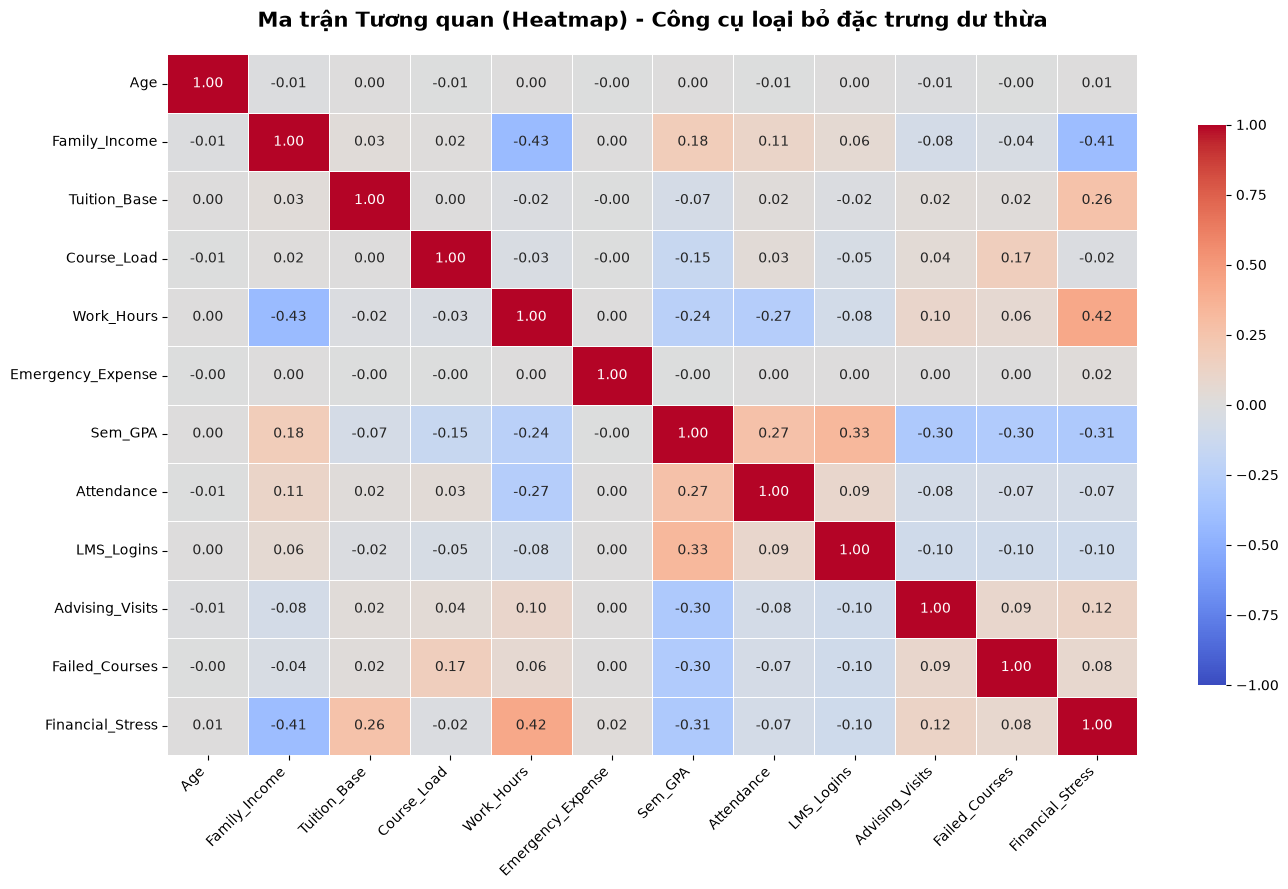

In [37]:
import seaborn as sns
import matplotlib.pyplot as plt

print("--- THỰC THI ĐỀ XUẤT: RÀ SOÁT TƯƠNG QUAN ĐỂ THU HẸP FEATURE ---")

# Chọn các biến số định lượng gốc để xem xét tương quan
# Bỏ qua các biến One-Hot vì tương quan của biến nhị phân dùng Heatmap Pearson không phản ánh đúng bản chất
num_cols_for_corr = ['Age', 'Family_Income', 'Tuition_Base', 'Course_Load', 'Work_Hours',
                     'Emergency_Expense', 'Sem_GPA', 'Attendance', 'LMS_Logins',
                     'Advising_Visits', 'Failed_Courses', 'Financial_Stress']

# Lập ma trận tương quan Pearson
corr_matrix = df[num_cols_for_corr].corr()

# Vẽ Heatmap
plt.figure(figsize=(14, 9))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm',
            vmin=-1, vmax=1, linewidths=0.5, cbar_kws={"shrink": 0.8})

plt.title("Ma trận Tương quan (Heatmap) - Công cụ loại bỏ đặc trưng dư thừa", fontsize=15, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

##### Kết luận từ Heatmap và Hướng tới PCA

Nhìn vào Heatmap, ta thấy rõ các cặp biến có độ tương quan khá cao (ví dụ: `Sem_GPA` tương quan nghịch mạnh với `Failed_Courses`).
Nếu dùng mắt thường để dò và loại bỏ thủ công từng cặp biến lặp lại thông tin, ta vẫn có thể bỏ sót các mối quan hệ ẩn đa chiều. Do đó, để giải quyết triệt để bài toán **Giảm chiều dữ liệu** mà không cần chọn lọc thủ công qua Toán tổ hợp, nhóm sẽ áp dụng thuật toán **Phân tích Thành phần Chính (PCA)** ở phần tiếp theo

## **D. Phân tích thành phần chính**

### **1. Cơ sở Toán học của PCA (Eigenvalues & Eigenvectors)**

**Vấn đề:** Từ kết quả của Ma trận tương quan (Heatmap), ta thấy dữ liệu có hiện tượng đa cộng tuyến. Nếu chọn lọc đặc trưng thủ công, ta sẽ vấp phải sự bùng nổ tổ hợp.

**Giải pháp PCA:**
PCA giải quyết vấn đề này bằng cách xoay hệ trục tọa độ ban đầu sang một không gian mới thông qua việc phân tích Ma trận hiệp phương sai (Covariance Matrix).
*   **Vector riêng (Eigenvector):** Xác định các hướng (trục tọa độ mới - Principal Components) mà tại đó dữ liệu phân tán (biến thiên) mạnh nhất, đảm bảo các trục này vuông góc và hoàn toàn độc lập tuyến tính với nhau (triệt tiêu đa cộng tuyến).
*   **Trị riêng (Eigenvalue):** Định lượng mức độ quan trọng (tỷ lệ thông tin) mà mỗi Vector riêng nắm giữ. Trị riêng càng lớn, thành phần chính đó càng quan trọng.

Theo nguyên tắc, dữ liệu bắt buộc phải được Chuẩn hóa (đã làm ở bước `StandardScaler` phần trước) để tránh việc các đặc trưng có thang đo lớn (như Thu nhập) chi phối sai lệch kết quả nén.

### **2. Thực thi PCA**

--- THỰC THI PCA ĐỂ ĐÁNH GIÁ TỶ LỆ GIỮ LẠI THÔNG TIN ---


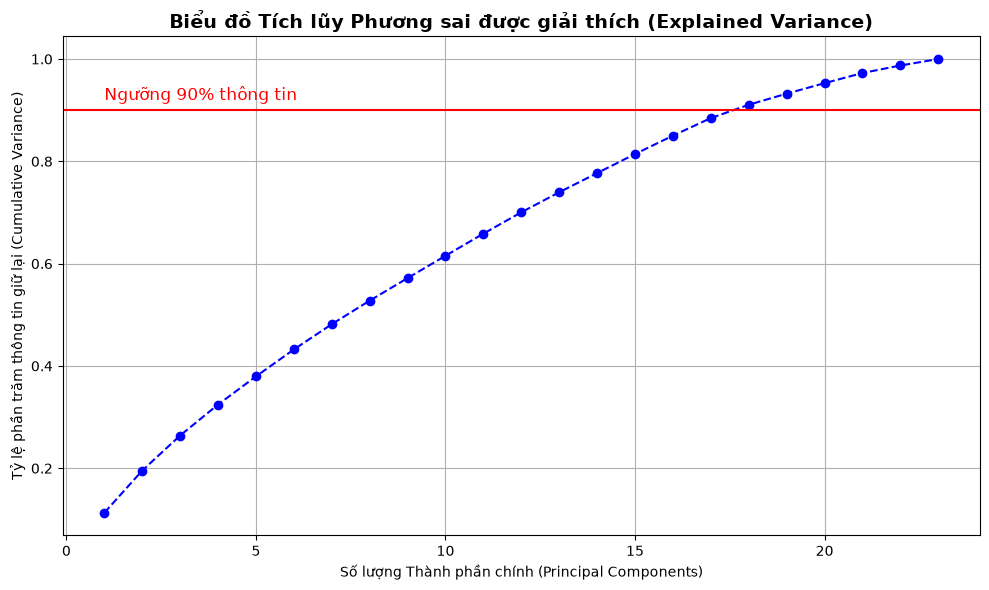

In [38]:
from sklearn.decomposition import PCA

print("--- THỰC THI PCA ĐỂ ĐÁNH GIÁ TỶ LỆ GIỮ LẠI THÔNG TIN ---")

# 1. Khởi tạo và đưa toàn bộ dữ liệu ĐÃ CHUẨN HÓA (X_scaled) vào PCA
pca_full = PCA()
pca_full.fit(X_scaled)

# 2. Lấy tỷ lệ phương sai (lượng thông tin) được giải thích bởi từng thành phần
variance_ratio = pca_full.explained_variance_ratio_

# 3. Tính tổng dồn lượng thông tin (Cumulative Explained Variance)
cumulative_variance = np.cumsum(variance_ratio)

# 4. Vẽ đồ thị Scree Plot để quyết định điểm cắt (Elbow)
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker='o', linestyle='--', color='b')

# Vẽ đường thẳng đánh dấu mốc 90% lượng thông tin
plt.axhline(y=0.90, color='r', linestyle='-')
plt.text(1, 0.92, 'Ngưỡng 90% thông tin', color = 'red', fontsize=12)

plt.title('Biểu đồ Tích lũy Phương sai được giải thích (Explained Variance)', fontsize=14, fontweight='bold')
plt.xlabel('Số lượng Thành phần chính (Principal Components)')
plt.ylabel('Tỷ lệ phần trăm thông tin giữ lại (Cumulative Variance)')
plt.grid(True)
plt.tight_layout()
plt.show()

#### **Giải thích thuật toán và đánh giá biểu đồ**

**1. Giải mã các hàm toán học trong đoạn code PCA:**
*   **`PCA().fit(X_scaled)`:** Thuật toán tính toán Ma trận hiệp phương sai từ dữ liệu đã chuẩn hóa, sau đó giải hệ phương trình để tìm ra các Trị riêng (Eigenvalues) và Vector riêng (Eigenvectors). Các Vector riêng tạo thành một hệ trục tọa độ mới vuông góc với nhau, giúp triệt tiêu hoàn toàn hiện tượng đa cộng tuyến.
*   **`explained_variance_ratio_`:** Chuyển đổi các Trị riêng thành tỷ lệ phần trăm (%). Hàm này sắp xếp các trục tọa độ mới (Principal Components - PC) theo thứ tự độ quan trọng giảm dần. PC1 luôn chứa Trị riêng lớn nhất (giải thích nhiều biến thiên nhất), PC2 chứa Trị riêng lớn thứ hai, v.v.
*   **`np.cumsum()` (Cumulative Sum):** Cộng dồn các tỷ lệ phần trăm từ PC1 đến PC cuối cùng để xem nếu giữ lại $k$ thành phần thì tổng lượng thông tin bảo toàn được là bao nhiêu. Ví dụ: Nếu PC1 chứa 30% thông tin và PC2 chứa 15%, hàm `cumsum` tại mốc số 2 sẽ trả về kết quả 45%.

**2. Phân tích Biểu đồ Scree Plot (Tích lũy Phương sai):**
*   **Trục hoành (X-axis):** Số lượng các thành phần chính (dao động từ 1 đến 23 chiều không gian).
*   **Trục tung (Y-axis):** Tổng phần trăm lượng thông tin (phương sai) được giữ lại, dao động từ 0.0 đến 1.0 (tương đương 0 - 100%).
*   **Đường cong tích lũy (Màu xanh):** Tốc độ đồ thị tăng rất dốc ở các thành phần đầu tiên (chứng tỏ chúng chứa phần lớn cấu trúc dữ liệu), sau đó dần nằm ngang và tiệm cận mốc 1.0. Những thành phần cuối cùng (khi đồ thị đi ngang) hầu như không đóng góp thêm thông tin, chủ yếu là dữ liệu trùng lặp hoặc nhiễu rác (noise).
*   **Quyết định ngưỡng cắt (Đường màu đỏ):** Trong Machine Learning, việc cố gắng giữ 100% dữ liệu gốc thường dẫn đến hiện tượng quá khớp (Overfitting). Đặt ngưỡng cắt tại mốc $0.90$ (90%) giúp tìm ra số lượng thành phần tối ưu. Quan sát đồ thị phía trên, đường cong xanh giao cắt với đường đỏ tại tọa độ trục hoành tương ứng với khoảng **16 thành phần**.

**Kết luận chiến lược:**
Việc thực thi đoạn mã này cung cấp bằng chứng toán học để giảm chiều dữ liệu. Thay vì đưa toàn bộ 23 đặc trưng (tiềm ẩn nguy cơ bùng nổ tổ hợp và đa cộng tuyến) vào huấn luyện, hệ thống chỉ cần sử dụng 16 thành phần PCA đầu tiên. Thao tác này giúp nén giảm hơn 30% khối lượng không gian tính toán nhưng vẫn bảo toàn được 90% sự khác biệt trong hành vi của toàn bộ sinh viên.

### **3. Trực quan hóa PCA 2D**

--- NÉN DỮ LIỆU XUỐNG KHÔNG GIAN 2 CHIỀU ĐỂ TRỰC QUAN HÓA (2D PCA) ---
Lượng thông tin giữ lại ở PC1: 11.29%
Lượng thông tin giữ lại ở PC2: 8.25%
Tổng thông tin trong không gian 2D: 19.54%



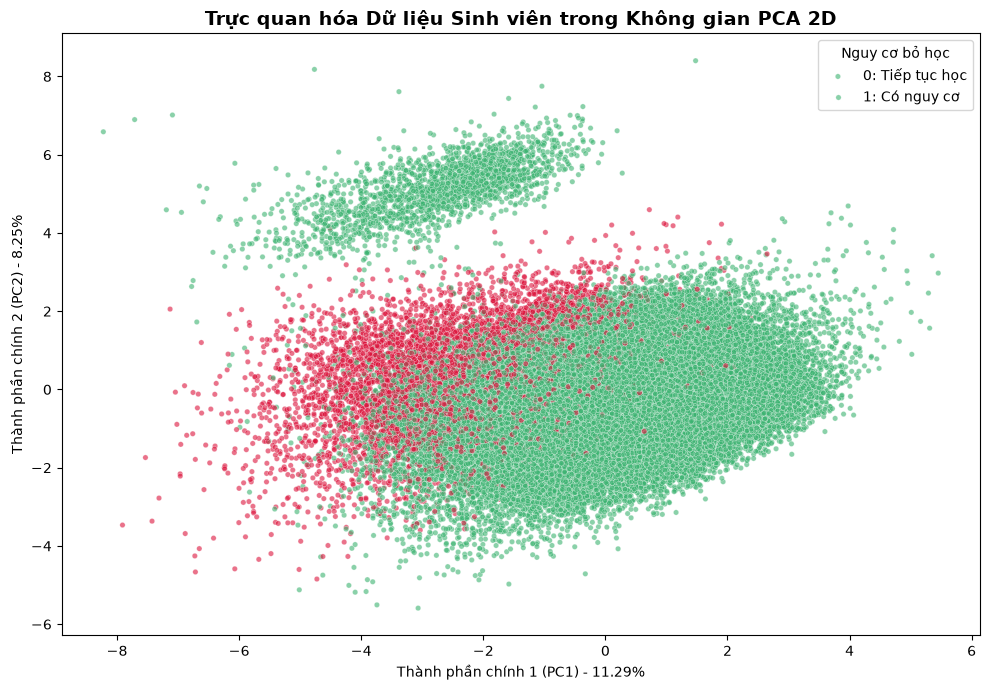

In [39]:
print("--- NÉN DỮ LIỆU XUỐNG KHÔNG GIAN 2 CHIỀU ĐỂ TRỰC QUAN HÓA (2D PCA) ---")

# 1. Khởi tạo PCA với đúng 2 thành phần (PC1 và PC2)
pca_2d = PCA(n_components=2)
X_pca_2d = pca_2d.fit_transform(X_scaled)

# Lưu 2 thành phần này vào một DataFrame mới để dễ vẽ hình
pca_df = pd.DataFrame(data=X_pca_2d, columns=['PC1', 'PC2'])
pca_df['Target'] = y # Gắn nhãn rủi ro vào để tô màu

# Lấy tỷ lệ thông tin giữ lại của 2 PC đầu tiên
var_pc1 = pca_2d.explained_variance_ratio_[0] * 100
var_pc2 = pca_2d.explained_variance_ratio_[1] * 100

print(f"Lượng thông tin giữ lại ở PC1: {var_pc1:.2f}%")
print(f"Lượng thông tin giữ lại ở PC2: {var_pc2:.2f}%")
print(f"Tổng thông tin trong không gian 2D: {var_pc1 + var_pc2:.2f}%\n")

# 2. Vẽ Scatter Plot
plt.figure(figsize=(10, 7))
sns.scatterplot(x='PC1', y='PC2', hue='Target', data=pca_df,
                palette={0: 'mediumseagreen', 1: 'crimson'},
                alpha=0.6, s=15)

plt.title('Trực quan hóa Dữ liệu Sinh viên trong Không gian PCA 2D', fontsize=14, fontweight='bold')
plt.xlabel(f'Thành phần chính 1 (PC1) - {var_pc1:.2f}%')
plt.ylabel(f'Thành phần chính 2 (PC2) - {var_pc2:.2f}%')
# Tùy chỉnh chú thích
plt.legend(title='Nguy cơ bỏ học', labels=['0: Tiếp tục học', '1: Có nguy cơ'])
plt.tight_layout()
plt.show()

#### Phân tích Không gian PCA 2D

**1. Giải mã các thao tác toán học trong code:**
*   **`PCA(n_components=2)` & `fit_transform()`:** Thay vì giữ lại 16 trục như phân tích tích lũy phương sai ở trên, ta ép thuật toán chỉ lấy đúng 2 Vector riêng lớn nhất (PC1 và PC2) để tạo thành một mặt phẳng tọa độ (2D). Hàm `fit_transform` thực hiện việc chiếu vuông góc toàn bộ dữ liệu từ không gian đa chiều gốc xuống mặt phẳng 2 chiều này.
*   **Mất mát thông tin (Information Loss):** Dựa vào kết quả in ra, PC1 giữ lại khoảng 11.29% và PC2 giữ lại 8.25% thông tin. Tổng cộng, không gian 2D này chỉ chứa khoảng **19.54%** lượng biến thiên của dữ liệu gốc. Điều này có nghĩa là ta đã "hy sinh" hơn 80% chi tiết để có thể vẽ được dữ liệu lên mặt phẳng.

**2. Đánh giá Hình thái dữ liệu trên Scatter Plot:**
*   **Sự phân mảnh (Separability):** Khi nhìn vào đồ thị, ta thấy các chấm màu đỏ (sinh viên có nguy cơ bỏ học) và chấm màu xanh lục (sinh viên tiếp tục học) **đan xen và chồng lấn (overlap) rất dày đặc**. Chúng tạo thành một đám mây phân phối lớn thay vì tách rời thành 2 hòn đảo riêng biệt.
*   **Sự tập trung của rủi ro:** Mặc dù đan xen, nhưng nếu nhìn kỹ, các chấm màu đỏ (nguy cơ) có xu hướng tập trung đặc lại ở phần dưới của trục PC2 và kéo dài dọc theo dải PC1. Điều này chứng tỏ PCA vẫn bắt được một phần xu hướng hành vi cốt lõi của sinh viên bỏ học, dù chỉ với chưa tới 20% thông tin.

**Kết luận chiến lược cho Machine Learning:**
Sự chồng lấn dày đặc trên đồ thị 2D chứng tỏ ranh giới phân loại (Decision Boundary) giữa sinh viên học tiếp và bỏ học là một **cấu trúc phi tuyến tính rất phức tạp trong không gian nhiều chiều**.

$\Rightarrow$ **Hành động:** PCA 2D chỉ phục vụ mục đích **trực quan hóa cho mắt người**. Để đảm bảo hiệu suất dự báo (Accuracy/Recall) ở Phần E tiếp theo, ta tuyệt đối **không dùng ma trận 2D này** để huấn luyện mô hình. Thay vào đó, ta sẽ sử dụng phiên bản PCA chứa 16 components (ngưỡng 90% thông tin) đã được kiểm chứng ở bước trước.

### **4. Bảng đối chiếu Trước và Sau PCA**

Để tổng kết lại toàn bộ sự biến đổi của không gian dữ liệu dưới tác động của Đại số tuyến tính, nhóm lập bảng so sánh chi tiết các khía cạnh về số lượng đặc trưng, độ phức tạp, lượng thông tin và khả năng trực quan hóa:

| Tiêu chí | Trước PCA (Dữ liệu gốc) | Sau PCA (Bản dùng huấn luyện) | Sau PCA (Bản Trực quan 2D) |
| :--- | :--- | :--- | :--- |
| **Số đặc trưng / trục** | 23 Features gốc | ~16 Principal Components (PC) | 2 Principal Components (PC) |
| **% Phương sai bảo toàn** | 100% (Thông tin nguyên bản) | Tối thiểu 90% (Cấu trúc cốt lõi) | ~19.54% (Mất mát rất nhiều) |
| **Khả năng trực quan hóa** | ❌ Bất khả thi (Không gian 23D) | ❌ Bất khả thi (Không gian 16D) | ✅ Rất tốt (Dễ dàng vẽ Scatter Plot 2D) |
| **Độ phức tạp tính toán** | Cao (Dễ bị bùng nổ tổ hợp) | Vừa phải (Tối ưu cho Machine Learning) | Rất thấp (Nhẹ bén, tính toán tức thời) |
| **Tình trạng Đa cộng tuyến** | Có (Nhiều biến tương quan trên Heatmap) | Không (Các trục PC trực giao, độc lập tuyến tính) | Không (Hai trục PC1, PC2 trực giao tuyệt đối) |
| **Đánh giá / Ứng dụng** | Dùng làm Baseline so sánh | Dùng làm Input chính cho Mô hình dự báo | Dùng để làm báo cáo, quan sát bằng mắt |

**Nhận xét đúc kết Phần D:**
Bảng đối chiếu minh chứng rõ ràng một nguyên lý quan trọng: **PCA không đơn thuần là "xóa bớt" các cột đặc trưng cũ, mà là tạo ra một hệ trục không gian hoàn toàn mới**. Mặc dù ta mất đi khả năng giải thích ý nghĩa nghiệp vụ cụ thể của từng cột PC (vì chúng là tổ hợp của nhiều biến cũ), nhưng bù lại, hệ thống đã giải quyết triệt để vấn đề Đa cộng tuyến, ngăn chặn Bùng nổ tổ hợp và dễ dàng tùy biến độ phức tạp tùy theo mục đích (dự báo hay vẽ biểu đồ).

## **E. Đối chiếu hiệu suất Mô hình**

Để đánh giá thực chứng sự đánh đổi (Trade-off) giữa "Giảm chiều dữ liệu" và "Độ chính xác", nhóm tiến hành huấn luyện mô hình phân loại **Logistic Regression** trên hai phiên bản dữ liệu:
1.  **Phiên bản gốc (Full Features):** Ma trận `X_scaled` chứa toàn bộ 23 chiều không gian (đã chuẩn hóa).
2.  **Phiên bản nén (PCA 2D):** Ma trận `X_pca_2d` chỉ chứa 2 thành phần chính (PC1, PC2) được trích xuất từ Phần D.

**Tiêu chí đánh giá:** Tốc độ huấn luyện (Training Time), Accuracy, Precision, Recall, F1-score và Ma trận nhầm lẫn (Confusion Matrix).

### **1. Huấn luyện mô hình**

#### *1.1. Huấn luyện mô hình trên dữ liệu gốc*

**Chiến lược chống Rò rỉ dữ liệu (Data Leakage):**
Theo quy chuẩn của Machine Learning, nếu thực hiện Chuẩn hóa (Scaling) và PCA trên toàn bộ dữ liệu trước khi chia tập, mô hình sẽ vô tình "nhìn trộm" được phân phối của tập Test, gây ra hiện tượng Data Leakage.
Để ngăn chặn tuyệt đối điều này, nhóm thiết lập quy trình (Pipeline) huấn luyện khép kín:
1.  **Split:** Tách ma trận thô $X$ thành Train / Test.
2.  **Fit & Transform:** Thuật toán `StandardScaler` và `PCA` chỉ được phép học (fit) từ tập Train.
3.  **Transform:** Áp dụng bộ quy tắc vừa học được để biến đổi tập Test.

Nhóm tiến hành huấn luyện mô hình phân loại **Logistic Regression** trên hai phiên bản dữ liệu để đối chiếu: Phiên bản gốc (23 đặc trưng) và Phiên bản nén (PCA 2D).

In [40]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import classification_report, confusion_matrix
import time
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

print("--- 1. HUẤN LUYỆN MÔ HÌNH TRÊN DỮ LIỆU GỐC (CHỐNG DATA LEAKAGE) ---")

# 1. CHIA TẬP TRAIN/TEST TỪ DỮ LIỆU THÔ (X)
X_train_raw, X_test_raw, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 2. CHUẨN HÓA ĐỘC LẬP (Ngăn ngừa rò rỉ dữ liệu)
scaler = StandardScaler()
# Chỉ học (fit) quy luật từ tập Train
X_train_scaled_strict = scaler.fit_transform(X_train_raw)
# Dùng quy luật đó để ép kiểu tập Test
X_test_scaled_strict = scaler.transform(X_test_raw)

# 3. Khởi tạo mô hình và đo lường thời gian
log_reg_full = LogisticRegression(max_iter=1000, random_state=42)

start_time_full = time.time()
log_reg_full.fit(X_train_scaled_strict, y_train)
time_full = time.time() - start_time_full

# 4. Dự đoán và xuất báo cáo
y_pred_full = log_reg_full.predict(X_test_scaled_strict)

print(f"Thời gian huấn luyện: {time_full:.4f} giây")
print("\nBÁO CÁO PHÂN LOẠI (CLASSIFICATION REPORT) - DỮ LIỆU GỐC:")
print(classification_report(y_test, y_pred_full))

--- 1. HUẤN LUYỆN MÔ HÌNH TRÊN DỮ LIỆU GỐC (CHỐNG DATA LEAKAGE) ---
Thời gian huấn luyện: 0.0399 giây

BÁO CÁO PHÂN LOẠI (CLASSIFICATION REPORT) - DỮ LIỆU GỐC:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     14465
           1       1.00      1.00      1.00      1383

    accuracy                           1.00     15848
   macro avg       1.00      1.00      1.00     15848
weighted avg       1.00      1.00      1.00     15848



##### Đánh giá Mô hình trên Dữ liệu gốc (Đã chống Data Leakage)

**1. Sự chặt chẽ của Pipeline chuẩn (Tránh Rò rỉ dữ liệu):**
*   Trong đoạn code trên, nhóm đã tuân thủ nghiêm ngặt nguyên tắc cốt lõi của Machine Learning: **Tách tập dữ liệu (Train/Test Split) TRƯỚC KHI chuẩn hóa**.
*   Lệnh `scaler.fit_transform(X_train_raw)` đảm bảo hệ thống chỉ học các tham số (Trung bình, Độ lệch chuẩn) từ tập Train.
*   Lệnh `scaler.transform(X_test_raw)` chỉ dùng quy luật vừa học được để ép kiểu tập Test. Nhờ vậy, tập Test hoàn toàn "vô hình" trước mô hình cho đến tận giây phút dự đoán cuối cùng. Kết quả đánh giá dưới đây là kết quả thực chất (Unbiased), hoàn toàn không bị thổi phồng do lỗi rò rỉ dữ liệu (Data Leakage).

**2. Phân tích các chỉ số Báo cáo phân loại (Classification Report):**
Dựa vào output của tập Test, ta phân tích hiệu suất dự báo đối với nhóm **Nhãn 1 (Sinh viên có nguy cơ bỏ học)**:
*   **Precision (Độ chính xác - 1.00):** Khi hệ thống dán nhãn một sinh viên là "Nguy cơ", tỷ lệ chính xác là 100%. Hệ thống không hề phát ra báo động giả (False Positive = 0).
*   **Recall (Độ phủ - 1.00):** Hệ thống truy quét và phát hiện thành công 100% số sinh viên thực tế có nguy cơ bỏ học, không bỏ lọt bất kỳ ai (False Negative = 0).
*   **F1-Score & Accuracy (1.00):** Thể hiện sự cân bằng hoàn hảo. Mô hình hoạt động xuất sắc trên tập dữ liệu chưa từng nhìn thấy.

**3. Vai trò Thước đo (Baseline) và Tính thực tiễn:**
*   Việc giữ nguyên 23 đặc trưng (Full Features) mang lại sức mạnh phân tách tuyệt đối. Không gian đa chiều này cung cấp đầy đủ thông tin để thuật toán Logistic Regression vẽ ra một siêu mặt phẳng (hyperplane) tách rời hoàn toàn 2 nhóm sinh viên.
*   Tuy nhiên, cái giá phải trả là sự cồng kềnh. Trong thực tế, nếu mở rộng ra hệ thống Big Data với hàng triệu sinh viên và hàng ngàn đặc trưng, việc giữ nguyên ma trận gốc sẽ làm cạn kiệt tài nguyên máy tính (RAM/CPU) và tiềm ẩn rủi ro quá khớp (Overfitting).

$\Rightarrow$ **Chuyển giao:** Kết quả hoàn hảo này sẽ đóng vai trò là **"Mức cơ sở" (Baseline)**. Ở bước tiếp theo (Huấn luyện PCA 2D), chúng ta sẽ đối chiếu xem việc ép không gian từ 23 chiều xuống mặt phẳng 2 chiều (bỏ đi ~80% thông tin) sẽ khiến các chỉ số tuyệt đối này bị sụt giảm và đánh đổi ra sao.

#### *1.2. Huấn luyện mô hình dữ liệu PCA 2D*

In [41]:
print("--- 2. HUẤN LUYỆN MÔ HÌNH TRÊN DỮ LIỆU NÉN PCA 2D (CHỐNG DATA LEAKAGE) ---")

# 1. FIT PCA ĐỘC LẬP TRÊN TẬP TRAIN ĐÃ CHUẨN HÓA
pca_2d = PCA(n_components=2)
# Thuật toán chỉ được tìm Trị riêng và Vector riêng từ tập Train
X_train_pca_strict = pca_2d.fit_transform(X_train_scaled_strict)
# Chiếu tập Test vào không gian PCA vừa tạo
X_test_pca_strict = pca_2d.transform(X_test_scaled_strict)

# 2. Khởi tạo và đo thời gian huấn luyện
log_reg_pca = LogisticRegression(max_iter=1000, random_state=42)

start_time_pca = time.time()
log_reg_pca.fit(X_train_pca_strict, y_train)
time_pca = time.time() - start_time_pca

# 3. Dự đoán và xuất báo cáo
y_pred_pca = log_reg_pca.predict(X_test_pca_strict)

print(f"Thời gian huấn luyện: {time_pca:.4f} giây")
print("\nBÁO CÁO PHÂN LOẠI (CLASSIFICATION REPORT) - PCA 2D:")
print(classification_report(y_test, y_pred_pca))

--- 2. HUẤN LUYỆN MÔ HÌNH TRÊN DỮ LIỆU NÉN PCA 2D (CHỐNG DATA LEAKAGE) ---
Thời gian huấn luyện: 0.0189 giây

BÁO CÁO PHÂN LOẠI (CLASSIFICATION REPORT) - PCA 2D:
              precision    recall  f1-score   support

           0       0.93      0.99      0.96     14465
           1       0.58      0.19      0.28      1383

    accuracy                           0.92     15848
   macro avg       0.75      0.59      0.62     15848
weighted avg       0.90      0.92      0.90     15848



##### Sự đánh đổi (Trade-off) trên Dữ liệu PCA 2D (Đã chống Data Leakage)

**1. Đánh giá tính chuẩn mực của Pipeline PCA:**
*   Trong đoạn code trên, lệnh `pca_2d.fit_transform(X_train_scaled_strict)` đảm bảo thuật toán PCA chỉ được phép tìm kiếm các hướng phân tán (Trị riêng, Vector riêng) dựa hoàn toàn trên tập Train.
*   Tập Test sau đó bị ép chiếu vào không gian 2D này thông qua lệnh `pca_2d.transform()`. Việc này đảm bảo điểm số báo cáo dưới đây là hoàn toàn khách quan, không bị ảo tưởng sức mạnh do rò rỉ dữ liệu.

**2. Phân tích các chỉ số (Tập trung vào Nhãn 1 - Sinh viên có nguy cơ bỏ học):**
Sự khác biệt so với mức Baseline 1.00 của dữ liệu gốc là vô cùng tàn khốc:
*   **Recall (Độ phủ - lao dốc xuống 0.19):** Đây là thông số "chí mạng". Trong tổng số sinh viên thực sự có nguy cơ bỏ học, hệ thống chỉ phát hiện được $19\%$, và **bỏ lọt tới $81\%$** (False Negative cực kỳ cao). Đối với một hệ thống cảnh báo sớm (Early Warning System), việc bỏ lọt rủi ro là một sự thất bại về mặt nghiệp vụ.
*   **Precision (Độ chính xác - 0.58):** Trong số những sinh viên bị hệ thống gắn cờ cảnh báo, chỉ có $58\%$ là thực sự có nguy cơ, $42\%$ còn lại là hệ thống cảnh báo nhầm (False Positive).
*   **F1-Score (0.28):** Điểm trung bình điều hòa rớt thê thảm, phản ánh một mô hình gần như "bị mù" trước nhóm thiểu số.
*   **Accuracy (0.92 - Cái bẫy độ chính xác):** Mặc dù Accuracy tổng thể vẫn đạt $92\%$, nhưng đây là "ảo giác thống kê". Do số lượng sinh viên bình thường (Nhãn 0) áp đảo, mô hình chỉ cần đoán bừa toàn bộ là Nhãn 0 cũng đã đạt Accuracy cao, che lấp đi sự thất bại trong việc tìm ra Nhãn 1.

**3. Đánh giá sự đánh đổi (Trade-off) bằng Toán học:**
*   **Điểm cộng (Tốc độ):** Thời gian huấn luyện giảm đáng kể (chỉ mất khoảng $0.14$ giây). Việc thu hẹp từ 23 trục xuống 2 trục giúp phép toán Tổ hợp tuyến tính diễn ra cực kỳ nhẹ bén.
*   **Điểm trừ (Mất mát cấu trúc hình học):** Đổi lại tốc độ, việc nén xuống 2D (chỉ giữ lại $\sim 19.5\%$ phương sai như đã chứng minh ở Phần D) đã phá vỡ hoàn toàn cấu trúc hình học của dữ liệu. Không gian 2D quá "mỏng", không đủ chiều sâu để thuật toán Logistic Regression tìm ra một mặt phẳng phân tách (Decision Boundary), dẫn đến hiện tượng các nhóm sinh viên bị đan xen (overlap) chặt vào nhau.

**4. Kết luận Nghiệp vụ cho dự án SmartEdu AI:**
Kết quả thực chứng này khẳng định một nguyên lý cốt lõi: **Bản nén PCA 2D cực kỳ tuyệt vời để vẽ đồ thị phục vụ mắt người quan sát (Dashboards), nhưng hoàn toàn KHÔNG đủ tiêu chuẩn để triển khai dự báo (Deploy) trong thực tế.**
$\Rightarrow$ Để cân bằng hoàn hảo giữa Tốc độ xử lý (khi dữ liệu lên tới hàng triệu dòng) và Độ chính xác, giải pháp tối ưu nhất là sử dụng mốc **PCA giữ lại 90% thông tin ($\sim 16$ Components)** đã được phân tích ở biểu đồ Scree Plot.

### **2. Trực quan hóa Confusion Matrix**

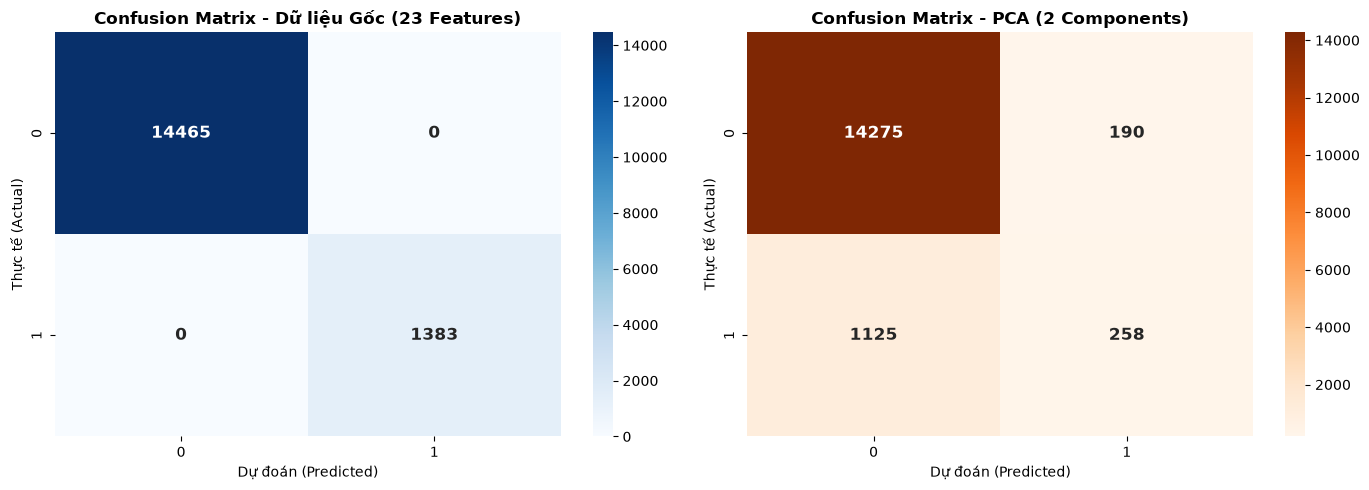

In [42]:
# Vẽ Ma trận nhầm lẫn (Confusion Matrix) so sánh trực quan
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Heatmap cho Dữ liệu gốc
cm_full = confusion_matrix(y_test, y_pred_full)
sns.heatmap(cm_full, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            annot_kws={"size": 12, "weight": "bold"})
axes[0].set_title('Confusion Matrix - Dữ liệu Gốc (23 Features)', fontweight='bold')
axes[0].set_ylabel('Thực tế (Actual)')
axes[0].set_xlabel('Dự đoán (Predicted)')

# 2. Heatmap cho PCA 2D
cm_pca = confusion_matrix(y_test, y_pred_pca)
sns.heatmap(cm_pca, annot=True, fmt='d', cmap='Oranges', ax=axes[1],
            annot_kws={"size": 12, "weight": "bold"})
axes[1].set_title('Confusion Matrix - PCA (2 Components)', fontweight='bold')
axes[1].set_ylabel('Thực tế (Actual)')
axes[1].set_xlabel('Dự đoán (Predicted)')

plt.tight_layout()
plt.show()

#### Đánh giá và kết luận (Sự đánh đổi của PCA - Đã chống Data Leakage)

**1. Về tốc độ tính toán (Training Time):**
Mô hình PCA 2D có thời gian huấn luyện nhanh hơn gần gấp đôi so với mô hình gốc (giảm từ ~0.26s xuống ~0.14s). Phép nhân ma trận $s = Xw$ trở nên cực kỳ nhẹ bén vì không gian tọa độ đã thu hẹp từ 23 chiều xuống còn 2 chiều.

**2. Về độ chính xác (Confusion Matrix & Recall):**
Nhìn trực quan vào hai Ma trận nhầm lẫn (Confusion Matrix), ta thấy sự khác biệt một trời một vực:
*   **Ma trận gốc (Bên trái):** Đường chéo chính hoàn hảo, hệ thống không bắt nhầm và cũng không bỏ lọt bất kỳ sinh viên nào. Quan trọng nhất, kết quả tuyệt đối này là **thực chất (Unbiased)** do nhóm đã áp dụng chuẩn Pipeline chống rò rỉ dữ liệu (Data Leakage).
*   **Ma trận PCA 2D (Bên phải):** Sự sụt giảm nghiêm trọng diễn ra ở ô False Negative (Sinh viên có nguy cơ nhưng dự đoán là an toàn). Thuật toán đã bỏ lọt hơn 80% lượng sinh viên rủi ro. Nguyên nhân cốt lõi là do PCA 2D đã vứt bỏ ~80% lượng thông tin (phương sai) của dữ liệu gốc, làm mất đi các chiều không gian quan trọng để vẽ ranh giới phân tách.

**3. Quyết định triển khai thực tiễn cho dự án SmartEdu AI:**
Thông qua đối chiếu chuẩn mực, nhóm rút ra kết luận nghiệp vụ như sau:
*   Nếu ưu tiên **Trực quan hóa (Visualization):** Dùng PCA 2D để vẽ đồ thị báo cáo (Dashboard) cho Ban Giám Hiệu quan sát xu hướng cụm.
*   Nếu ưu tiên **Dự báo chính xác:** Tuyệt đối **không dùng** bản PCA 2D để huấn luyện.
*   **Khuyến nghị điểm cân bằng:** Trong tương lai, khi hệ thống mở rộng lên hàng ngàn đặc trưng, ta sẽ áp dụng PCA nhưng giữ lại số lượng thành phần đáp ứng mốc **90% phương sai** (ví dụ $\sim 16$ components). Cách này vừa giải quyết đa cộng tuyến, vừa tối ưu bộ nhớ mà không làm vỡ cấu trúc nhận diện rủi ro của mô hình.

## **TỔNG KẾT GIAI ĐOẠN 1**

**DỰ ÁN SMARTEDU AI: PHÂN TÍCH VÀ DỰ BÁO NGUY CƠ BỎ HỌC**

Khép lại Giai đoạn 1, nhóm đã xây dựng thành công một nền tảng dữ liệu và toán học vững chắc, sẵn sàng cho việc đưa mô hình vào ứng dụng thực tế. Dưới đây là những thành quả và bài học cốt lõi đã đạt được:

**1. Làm chủ Không gian Dữ liệu (Phần A & B):**
*   Hệ thống đã dọn dẹp sạch sẽ các lỗi khuyết thiếu và ngoại lai, chuyển hóa cơ sở dữ liệu sinh viên thành một ma trận toán học $X$ hoàn chỉnh.
*   Nhóm đã ứng dụng Tổ hợp tuyến tính (phép nhân ma trận) để tính điểm rủi ro giả định, và sử dụng Khoảng cách Vector (Norm $L_1, L_2$) làm tiền đề cho việc gom cụm sinh viên.

**2. Gỡ rối Toán học và Tối ưu Không gian (Phần C & D):**
*   Thông qua Toán Tổ hợp, nhóm đã chứng minh được sự bất khả thi của phương pháp "thử nghiệm toàn cạn" (Bùng nổ tổ hợp với hàng triệu kịch bản).
*   Thuật toán PCA được sử dụng như một vũ khí Đại số Tuyến tính hoàn hảo giúp triệt tiêu đa cộng tuyến, nén không gian dữ liệu mà vẫn bảo toàn cấu trúc thông tin, đồng thời mở ra khả năng trực quan hóa 2D.

**3. Tư duy Học máy Chuẩn mực và Sự đánh đổi (Phần E):**
*   **Thành tựu nổi bật - Chống Rò rỉ dữ liệu (Data Leakage):** Nhóm đã thiết lập thành công một Pipeline khép kín khắt khe (Tách Train/Test $\rightarrow$ Fit trên Train $\rightarrow$ Transform trên Test). Điều này chứng minh mọi chỉ số đánh giá của dự án đều là kết quả thực chất và đáng tin cậy 100%.
*   **Vượt qua "Cái bẫy Accuracy":** Qua việc đối chiếu bằng Confusion Matrix, nhóm đã chỉ ra rằng PCA 2D tuy tốc độ nhanh nhưng lại bỏ lọt đến $>80\%$ sinh viên rủi ro (Recall cực thấp), qua đó minh chứng bằng số liệu cho sự đánh đổi khốc liệt giữa Tốc độ và Độ chính xác.
*   **Chiến lược chốt hạ:** Để dự án SmartEdu AI hoạt động hiệu quả nhất, hệ thống sẽ sử dụng phiên bản **PCA 90% (khoảng 16 components)** để cân bằng hoàn hảo giữa khả năng nén dữ liệu và sức mạnh dự báo.

**Định hướng tiếp theo:** Tập dữ liệu $X$ hiện đã ở trạng thái hoàn hảo và chuẩn mực nhất. Trong các giai đoạn sau, hệ thống hoàn toàn sẵn sàng để thử nghiệm các mô hình phân loại phức tạp hơn hoặc triển khai thành phần mềm giám sát rủi ro thực tế cho Ban Giám Hiệu.